# EDA анализ банковских транзакций

Анализ банковских транзакций от Сбера (на тот момент Сбербанка).

Ссылка на соревнование: https://ods.ai/competitions/sberbank-sirius-lesson

### Введение

<img align=right src="https://storage.yandexcloud.net/datasouls-competitions/sirius/pic/1_2.png" style="width:500px;" />

Глобально вопрос звучит так: можно ли узнать возраст клиента на основе информации о его расходах по карте?

Сбербанк подготовил задачу на базе реальных банковских транзакций.

Совершенствуя свои продукты, банк использует информацию о пользователях, в том числе и возраст. Это помогает сделать персонализированные продукты, которые удовлетворяют реальным потребностям клиентов.

**В этом задании требуется определить, есть ли разница в характере и типах трат между клиентами банка разных возрастов.**



### Исследовательский анализ данных (EDA)

Моя задача — исследовать информацию о расходах клиента банка и выяснить, по какой информации из транзакций - сумма транзакции, время транзакции, категория трат транзакиции или что-то еще - можно отличить клиентов банка разных возрастных категорий. Для этого вам нужно провести исследовательский анализ данных и выяснить, в чем же заключаются различия между тратами с карты у людей разного возраста.

### Данные

<img align=right src="https://storage.yandexcloud.net/datasouls-competitions/sirius/pic/1_5.png" style="width:500px;" />


Для решения данной задачи предоставляется информация о транзакциях клиентов банка - примерно 27М записей.

Каждая запись описывает одну банковскую транзакцию.

In [ ]:
!ls data

ls: cannot access 'data': No such file or directory


Предоставлен (набор данных) `transactions_train.csv`, в котором для каждой транзакции известна дата, сумма, тип и id клиента:

- `сlient_id` – уникальный номер клиента;
- `trans_date` – дата транзакции (представляет из себя просто номер дня в хронологическом порядке, начиная от заданной даты);
- `small_group` – группа транзакций, характеризующих тип транзакции (например, продуктовые магазины, одежда, заправки, детские товары и т.п.);
- `amount_rur` – сумма транзакции (для анонимизации данные суммы были трансформированы без потери структуры).


В файле `train_target.csv` содержится информация о Клиенте и метка возрастной группы, к которой он относится:

- `client_id` – уникальный номер Клиента (соответствует `client_id` из файла `transactions_train.csv`);
- `bins` – метка (от 0 до 3) одной из 4-х возрастных групп.

Файлы `test.csv` и `transactions_test.csv` не потребуются.

Также предоставляется информационный файл `small_group_description.csv`, который содержит расшифровку типов транзакций.

### Скачиваем данные


In [ ]:
# скачиваем архив с данными

!wget https://storage.yandexcloud.net/datasouls-competitions/sirius/data.zip

--2026-04-20 15:54:04--  https://storage.yandexcloud.net/datasouls-competitions/sirius/data.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 251394334 (240M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>] 239.75M  33.6MB/s    in 7.8s    

2026-04-20 15:54:13 (30.9 MB/s) - ‘data.zip’ saved [251394334/251394334]



In [ ]:
# разархивируем данные в директорию data/
!unzip data.zip -d './data/'

Archive:  data.zip
  inflating: ./data/test.csv         
   creating: ./data/__MACOSX/
  inflating: ./data/__MACOSX/._test.csv  
  inflating: ./data/small_group_description.csv  
  inflating: ./data/__MACOSX/._small_group_description.csv  
  inflating: ./data/train_target.csv  
  inflating: ./data/__MACOSX/._train_target.csv  
  inflating: ./data/transactions_train.csv  
  inflating: ./data/__MACOSX/._transactions_train.csv  
  inflating: ./data/transactions_test.csv  
  inflating: ./data/__MACOSX/._transactions_test.csv  


### Исследовательский анализ данных (EDA - Exploratory Data Analysis)

Далее я проведу анализ с помощью визуализации (`matplotlib` или `seaborn`).

Примерный набор вопросов, на которые стоит ответить с помощью анализа данных:

- как меняется число и сумма странзакций в разных возрастных категориях клиентов по дням месяца, по дням недели, по часам в дне?
- какая средняя сумма трат по возрастным группам за месяц?
- есть ли разница в среднем размере снимаемой в банкомате сумме для разных возрастных групп?
- какие самые частые по числу транзакций и самые большие по сумме покупок категории трат (```mcc_code```) для разных возрастных групп?
- есть ли характерные категории трат для разных возрастных групп?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Создала путь к директории `data` и вывела список содержимого:

https://docs.python.org/3/library/pathlib.html

In [ ]:
# ваш код тут
p = Path('data')
for i in [x for x in p.iterdir()]:
  print(i, end='\n')

data/train_target.csv
data/transactions_test.csv
data/__MACOSX
data/transactions_train.csv
data/test.csv
data/small_group_description.csv


Создала датафрейм `df_transactions` с транзакциями:

In [ ]:
# ваш код тут
df_transactions = pd.read_csv('data/transactions_train.csv')
df_transactions.head()

,client_id,trans_date,small_group,amount_rur
0,33172,6,4,71.463
1,33172,6,35,45.017
2,33172,8,11,13.887
3,33172,9,11,15.983
4,33172,10,11,21.341


Сколько строчек в датафрейме и какой размер памяти он занимает:

In [ ]:
# ваш код тут
print(df_transactions.shape)
print(df_transactions.info())

(26450577, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26450577 entries, 0 to 26450576
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   client_id    int64  
 1   trans_date   int64  
 2   small_group  int64  
 3   amount_rur   float64
dtypes: float64(1), int64(3)
memory usage: 807.2 MB
None


 В датафрейме df_transactions 26,450,577 строк. И он занимает 807.2 MB.

Считала файл `train_target.csv` с возрастными группами юзеров (назовите датафрейм `df_target`). Инофрмация по нему:

In [ ]:
# ваш код тут
df_target = pd.read_csv('data/train_target.csv')

print(df_target.shape)
print(df_target.info())
df_target.head()

(30000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  30000 non-null  int64
 1   bins       30000 non-null  int64
dtypes: int64(2)
memory usage: 468.9 KB
None


,client_id,bins
0,24662,2
1,1046,0
2,34089,2
3,34848,1
4,47076,3


В датафрейме df_target 30,000 строк.

Объединила (`df.merge`) две таблицы по ключу `client_id`.


In [ ]:
# ваш код тут
df_trans = pd.merge( df_transactions, df_target, how="outer", on="client_id")
df_trans

,client_id,trans_date,small_group,amount_rur,bins
0,4,0,1,10.209,1
1,4,2,3,27.706,1
2,4,3,1,13.024,1
3,4,4,1,17.632,1
4,4,6,4,18.089,1
...,...,...,...,...,...
26450572,49998,723,3,1.423,1
26450573,49998,726,3,2.290,1
26450574,49998,727,2,13.731,1
26450575,49998,728,34,1.786,1


In [ ]:
df_trans.nunique()

,0
client_id,30000
trans_date,730
small_group,202
amount_rur,503945
bins,4


В онсновниом датафрейме df_trans транзакции 30,000 уникальных клиентов, за 730 дней то есть ровно за 2 года.

In [ ]:
df_trans.isnull().sum()

,0
client_id,0
trans_date,0
small_group,0
amount_rur,0
bins,0


В датафрейме нет null значений.

In [ ]:
#настройки
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

plt.style.use('ggplot')

plt.rcParams.update({

  'figure.figsize': (12, 6),

  'axes.labelsize': 14,
  'axes.labelcolor': 'black',
  'axes.labelpad': 12,

  'axes.grid': True,
  'grid.alpha': 0.6,
  'grid.linestyle': '--',

  'xtick.labelsize': 12,
  'ytick.labelsize': 12,

  'axes.titlesize': 15,
  'axes.titlepad': 14

})

In [ ]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [ ]:
df_trans.head()

,client_id,trans_date,small_group,amount_rur,bins,dayofweek
0,4,0,1,10.209,1,4
1,4,2,3,27.706,1,6
2,4,3,1,13.024,1,0
3,4,4,1,17.632,1,1
4,4,6,4,18.089,1,3


In [ ]:
df_trans['dayofweek'] = df_trans['trans_date'].apply(lambda x: (x + 4) % 7)

In [ ]:
df_trans.dayofweek.value_counts()

,count
dayofweek,
2,4137792
1,3879517
3,3796904
0,3794513
6,3728485
5,3683643
4,3429723


# **Анализ транзакций**

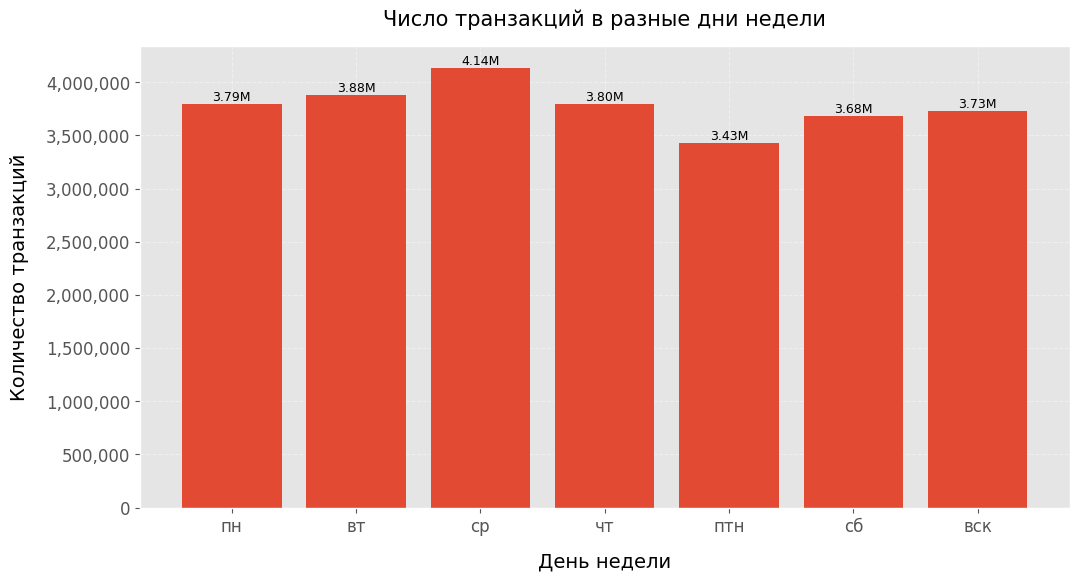

In [ ]:
plt.figure()
bars = plt.bar(df_trans.dayofweek.value_counts().index, df_trans.dayofweek.value_counts().values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height/1_000_000:.2f}M',
        ha='center', va='bottom',
        fontsize=9
    )

plt.title('Число транзакций в разные дни недели')
plt.xlabel('День недели')
plt.ylabel('Количество транзакций')
plt.xticks(ticks=range(7), labels = ['пн', 'вт', 'ср', 'чт', 'птн', 'сб', 'вск'])

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

На этом графике можно увидеть, что среда - пик активности (4.14М), а пятница - минимальный (3.43М). В целом, распределение довольно равномерное, разброс небольшой.

<Figure size 1200x600 with 0 Axes>

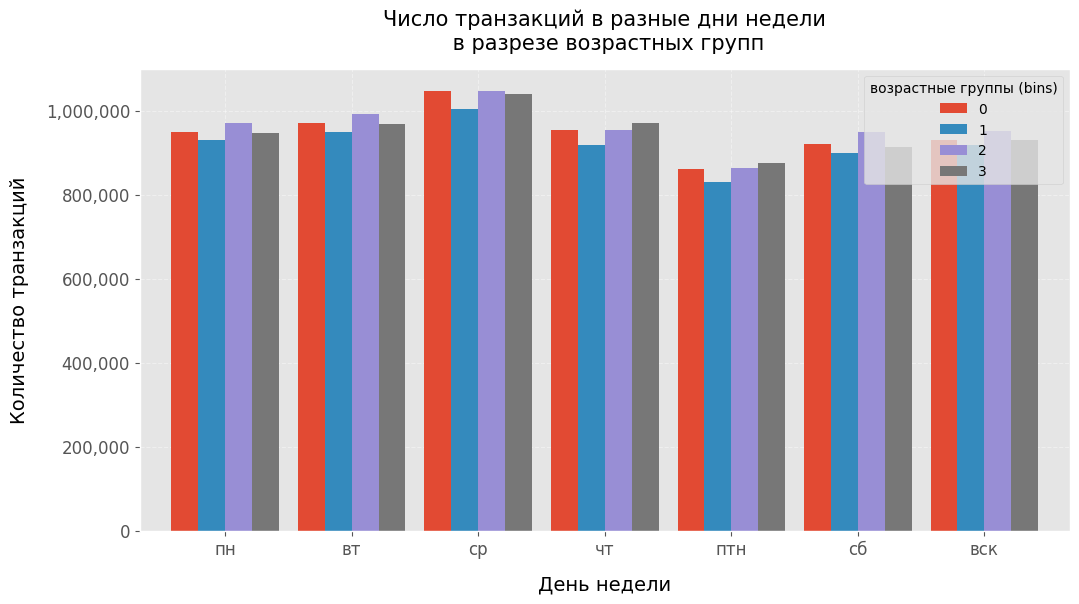

In [ ]:
plt.figure()


counts = df_trans.groupby(['dayofweek', 'bins']).size().unstack(fill_value=0)

counts.plot(kind='bar', width=0.85)


plt.xticks(ticks=range(7), labels = ['пн', 'вт', 'ср', 'чт', 'птн', 'сб', 'вск'])
plt.title('Число транзакций в разные дни недели\n в разрезе возрастных групп')
plt.ylabel('Количество транзакций')
plt.xlabel('День недели')
plt.legend(title='возрастные группы (bins)')
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

На этом графике можно заметить, что все 4 возрастные группы (0–3) ведут себя практически одинаково по дням недели — паттерн «среда-пик, пятница-минимум» воспроизводится у каждой группы. Столбики примерно равной высоты внутри каждого дня, а это значит что в каждой группе примерно производится примерно одинаковое количество транзакций в день. Поведенческая активность по дням универсальна для всех сегментов

In [ ]:
df_trans.groupby(['dayofweek', 'bins']).size().unstack(fill_value=0)

bins,0,1,2,3
dayofweek,,,,
0,949101,929614,969547,946251
1,970483,949129,991870,968035
2,1047843,1004218,1046459,1039272
3,953916,917211,954197,971580
4,861700,829926,863773,874324
5,921638,899253,948819,913933
6,929684,917572,951774,929455


In [ ]:
df_trans.trans_date.nunique() # уникальные значение - кол-во дней

730

In [ ]:
df_trans.trans_date.value_counts() # число транзакций по дням

,count
trans_date,
727,52330
726,50789
728,49675
725,49452
691,49207
...,...
1,21716
7,21304
6,20333


In [ ]:
df_smgp_desc = pd.read_csv('data/small_group_description.csv')

In [ ]:
print(df_smgp_desc.shape)
df_smgp_desc.head()

(204, 2)


,small_group,small_group_code
0,Зоотовары,0
1,Сетевые супермаркеты и продуктовые магазины,1
2,Обслуживание существующего автомобиля (АЗС),2
3,Оплата телефона и связи,3
4,Аптеки,4


В датафрэйме small_group_description 204 строк. А это значит, что категорий у нас всего 204.

In [ ]:
df_desc = df_trans.merge(df_smgp_desc, how='left', left_on='small_group', right_on='small_group_code')


In [ ]:
print(df_desc.shape)
df_desc.head()

(26450577, 8)


,client_id,trans_date,small_group_x,amount_rur,bins,dayofweek,small_group_y,small_group_code
0,4,0,1,10.209,1,4,Сетевые супермаркеты и продуктовые магазины,1
1,4,2,3,27.706,1,6,Оплата телефона и связи,3
2,4,3,1,13.024,1,0,Сетевые супермаркеты и продуктовые магазины,1
3,4,4,1,17.632,1,1,Сетевые супермаркеты и продуктовые магазины,1
4,4,6,4,18.089,1,3,Аптеки,4


In [ ]:
df_desc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26450577 entries, 0 to 26450576
Data columns (total 8 columns):
 #   Column            Dtype  
---  ------            -----  
 0   client_id         int64  
 1   trans_date        int64  
 2   small_group_x     int64  
 3   amount_rur        float64
 4   bins              int64  
 5   dayofweek         int64  
 6   small_group_y     object 
 7   small_group_code  int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 1.6+ GB


In [ ]:
df_desc.describe()

,client_id,trans_date,small_group_x,amount_rur,bins,dayofweek,small_group_code
count,2.645058e+07,2.645058e+07,2.645058e+07,2.645058e+07,2.645058e+07,2.645058e+07,2.645058e+07
mean,2.500256e+04,3.926793e+02,1.427400e+01,5.586215e+01,1.505765e+00,2.950931e+00,1.427400e+01
std,1.444861e+04,2.070200e+02,2.046108e+01,3.694852e+02,1.119774e+00,1.996795e+00,2.046108e+01
min,4.000000e+00,0.000000e+00,0.000000e+00,1.000000e-03,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.251900e+04,2.200000e+02,1.000000e+00,9.057000e+00,0.000000e+00,1.000000e+00,1.000000e+00
50%,2.503200e+04,4.070000e+02,9.000000e+00,1.988200e+01,2.000000e+00,3.000000e+00,9.000000e+00
75%,3.748900e+04,5.720000e+02,1.800000e+01,4.579500e+01,3.000000e+00,5.000000e+00,1.800000e+01
max,4.999800e+04,7.290000e+02,2.030000e+02,4.000868e+05,3.000000e+00,6.000000e+00,2.030000e+02


In [ ]:
df_desc.rename(columns={'small_group_y': 'small_group'}, inplace=True)
df_desc.drop(columns='small_group_x', inplace=True)
df_desc.head()

,client_id,trans_date,amount_rur,bins,dayofweek,small_group,small_group_code
0,4,0,10.209,1,4,Сетевые супермаркеты и продуктовые магазины,1
1,4,2,27.706,1,6,Оплата телефона и связи,3
2,4,3,13.024,1,0,Сетевые супермаркеты и продуктовые магазины,1
3,4,4,17.632,1,1,Сетевые супермаркеты и продуктовые магазины,1
4,4,6,18.089,1,3,Аптеки,4


In [ ]:
trans_types = df_desc.groupby('small_group_code').size()

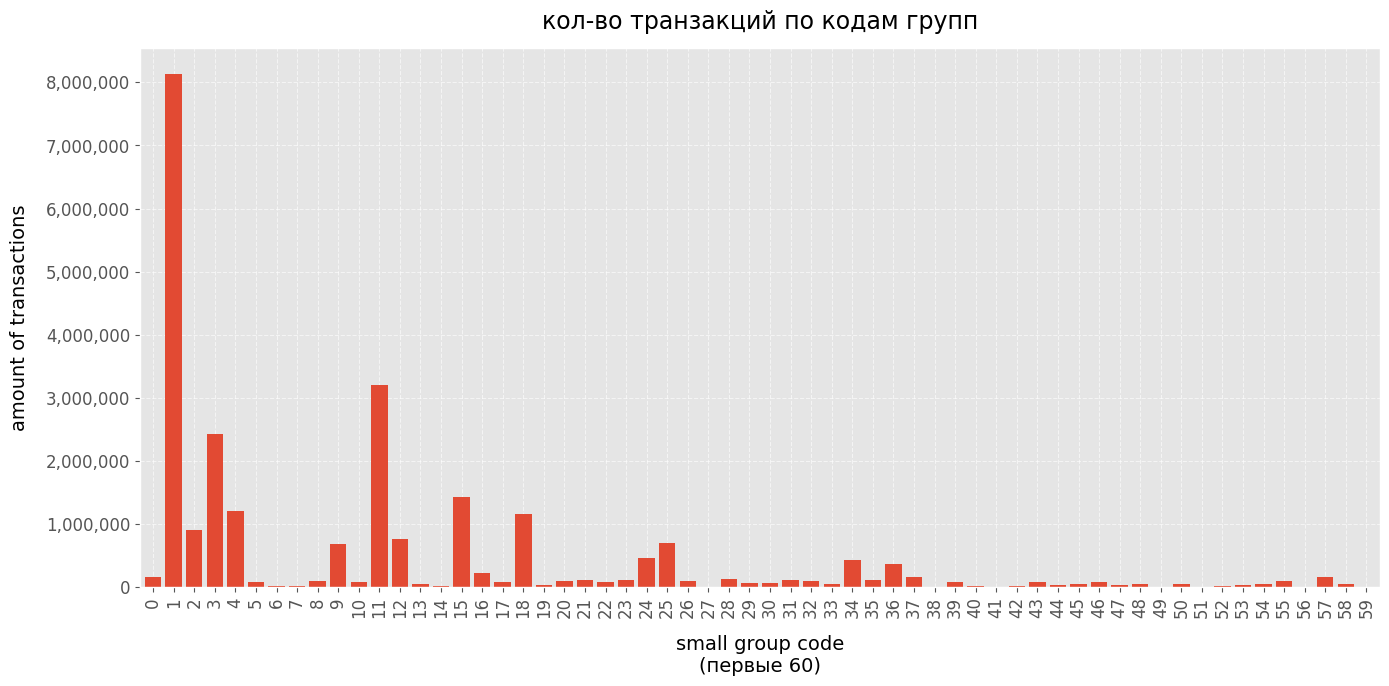

In [ ]:
plt.figure(figsize=(16, 7))

trans_types.iloc[:60].plot(kind='bar', width=0.8 )
plt.xlabel('small group code\n(первые 60)')
plt.ylabel('amount of transactions')
plt.title('кол-во транзакций по кодам групп', fontsize=17)

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

На данном графике показаны количества транзакций по кодам групп. Были взяты первые 60 кодов для наглядности, после еще меньше по кол-ву транзакций. Мы можем наблюдать сильный дисбаланс.

In [ ]:
small_groups = df_desc.groupby(by=['small_group_code']).size()

In [ ]:
small_groups.name = 'count'
small_groups.head()

,count
small_group_code,
0,165773
1,8131374
2,908408
3,2428984
4,1207604


In [ ]:
small_groups = small_groups.reset_index()

In [ ]:
small_groups = small_groups.merge(df_smgp_desc, how='left', on='small_group_code')

In [ ]:
small_groups = small_groups.sort_values(by='count', ascending=False)

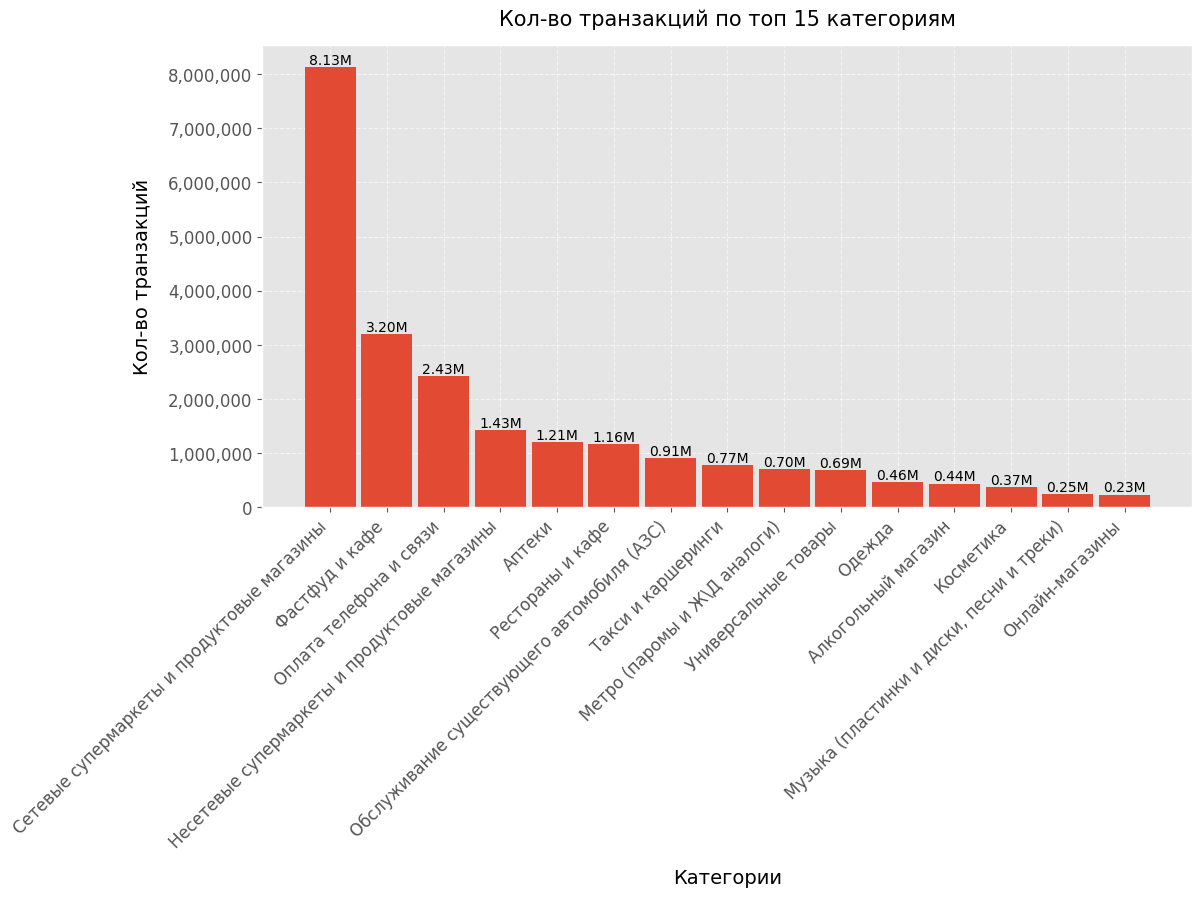

In [ ]:
plt.figure()

bars = plt.bar(small_groups.iloc[:15]['small_group'], small_groups.iloc[:15]['count'], width=0.9 )

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height/1_000_000:.2f}M',
        ha='center', va='bottom'
    )

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45, ha='right') # ha - aligns nicely
plt.xlabel('Категории')
plt.ylabel('Кол-во транзакций')
plt.title('Кол-во транзакций по топ 15 категориям')
#plt.tick_params(axis='x', labelsize=15)
plt.show()

Были взяты первые 15 категорий для наглядности, так как их всего 204. Далее, показатели еще меньше. На данном графике мы можем видеть абсолютное доминирование супермаркетов (8.13M) - почти в 2.5 раза больше второй категории (фастфуд, 3.20M). Далее — телефония, несетевые магазины, аптеки. Хвост длинный и быстро убывает. Мы видим на каких категориях держится основной оборот. Супермаркеты и фастфуд - это ежедневные базовые нужны среди всех возрастных групп.

In [ ]:
small_groups.head()

,small_group_code,count,small_group
1,1,8131374,Сетевые супермаркеты и продуктовые магазины
11,11,3202881,Фастфуд и кафе
3,3,2428984,Оплата телефона и связи
15,15,1427077,Несетевые супермаркеты и продуктовые магазины
4,4,1207604,Аптеки


In [ ]:
stacked_bar = df_desc.groupby(by=['small_group', 'bins']).size().unstack(fill_value=0)
stacked_bar['counts'] = stacked_bar.sum(axis=1)
stacked_bar = stacked_bar.sort_values(by='counts', ascending=False).head(15)
stacked_bar = stacked_bar.drop(columns='counts')
stacked_bar

bins,0,1,2,3
small_group,,,,
Сетевые супермаркеты и продуктовые магазины,1847354,2344264,1918899,2020857
Фастфуд и кафе,866037,514282,1127350,695212
Оплата телефона и связи,581206,600087,610782,636909
Несетевые супермаркеты и продуктовые магазины,343361,402225,339343,342148
Аптеки,271905,400057,221162,314480
Рестораны и кафе,323218,240720,313102,281472
Обслуживание существующего автомобиля (АЗС),248933,234336,143942,281197
Такси и каршеринги,249254,76236,304344,143971
Метро (паромы и Ж\Д аналоги),181184,96864,277225,147623


<Figure size 1200x600 with 0 Axes>

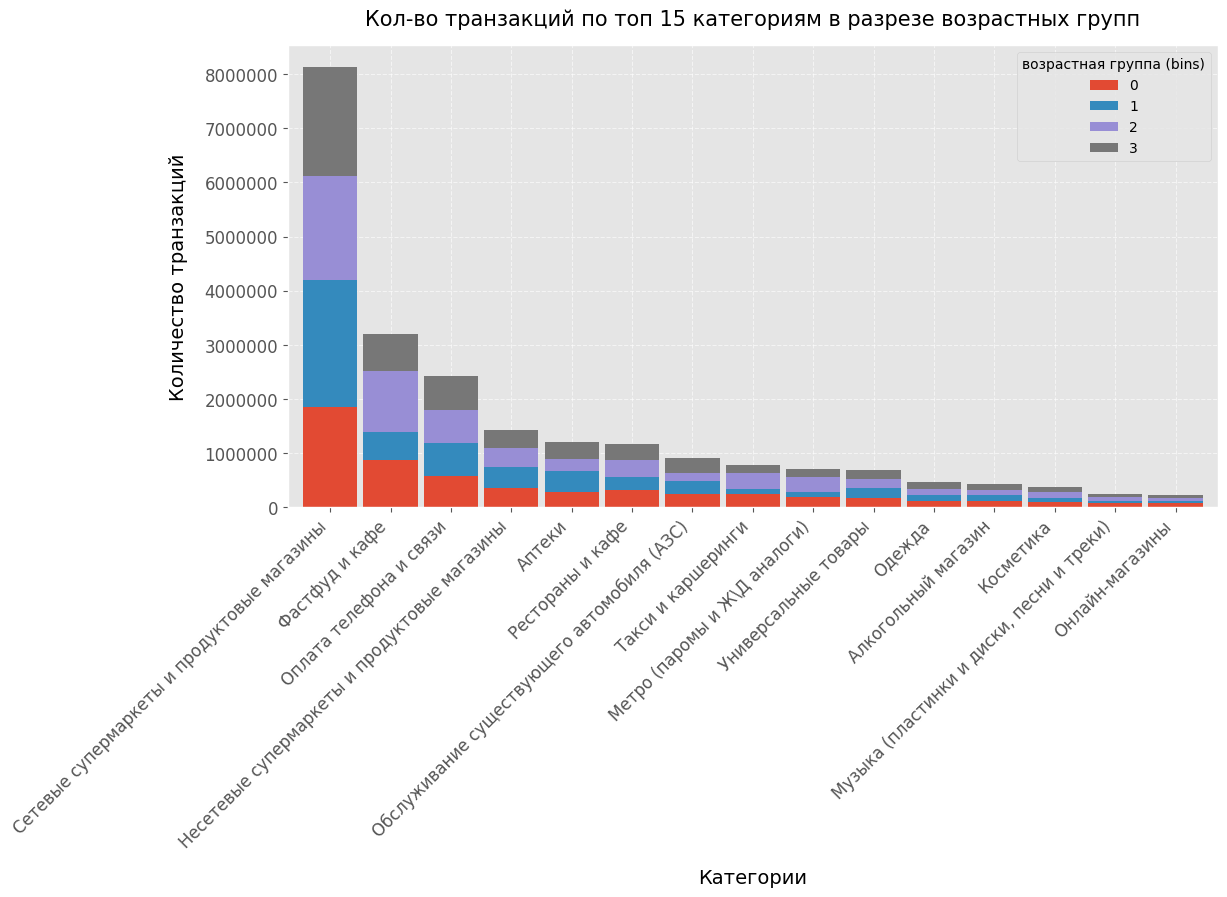

In [ ]:
plt.figure()

stacked_bar.plot(kind='bar', stacked=True, width=0.9)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Категории')
plt.ylabel('Количество транзакций')
plt.title('Кол-во транзакций по топ 15 категориям в разрезе возрастных групп')
plt.legend(title='возрастная группа (bins)')
plt.show()

На этом графике можем наблюдать резкий спад кол-ва транзакций. В основном преобладает категория "Сетевые супермаркеты и продуктовые магазины", и в ней доли возрастных групп примерно пропорциональны - стопки сбалансированы. Это самая актуальная категория трат для всех возрастных групп, и в каждой она заметно лидирует среди остальных топ категорий. В остальных же категориях мы можем заметить, что пропорции слегка сдвигаются.

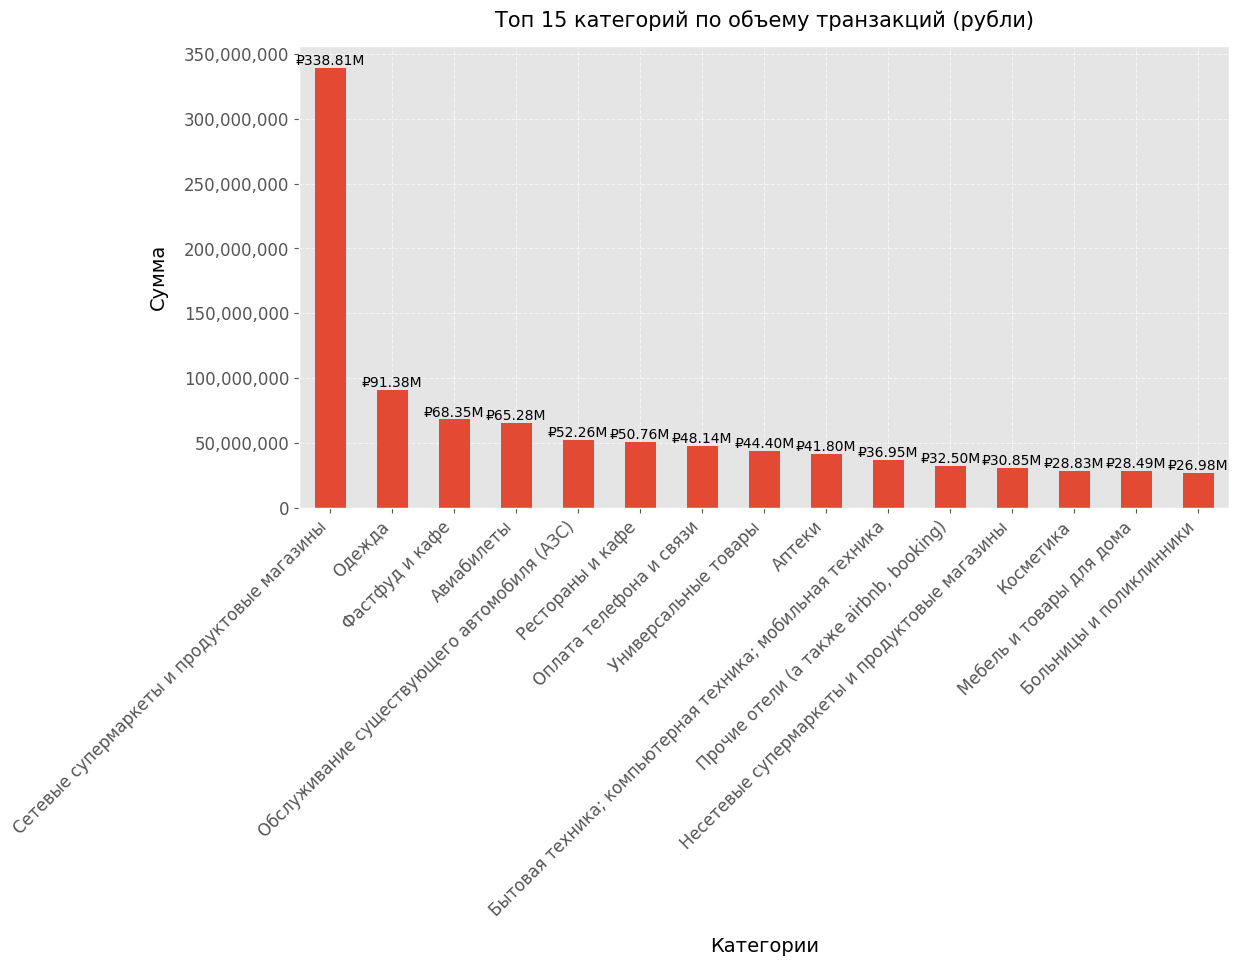

In [ ]:
plt.figure(figsize=(16, 8))

ax = df_desc.groupby(by=['small_group'])['amount_rur'].sum().sort_values(ascending=False).head(15).plot(kind='bar')

for bar in ax.patches:  # ← исправлено: ax.patches вместо ax
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height/1_000_000:.2f}M',
        ha='center', va='bottom'
    )

plt.title('Топ 15 категорий по объему транзакций (рубли)')
plt.xlabel('Категории')
plt.ylabel('Сумма')
plt.xticks(rotation=45, ha='right')

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

Этот график показывает рейтинг по деньгам, а не по количеству. Супермаркеты всё равно лидируют (338M), но второе место - одежда (91M), которой почти не было в топе по количеству транзакций. Авиабилеты, АЗС, рестораны тоже в топе.
Из этого можно судить, что одежда - редкие, но дорогие покупки. Это важно для профилирования возрастных групп: кто покупает одежду на крупные суммы? Два рейтинга (по количеству vs по сумме) дают разную картину: частые мелкие транзакции - это оборот, крупные редкие - это маржа.

<Figure size 1600x800 with 0 Axes>

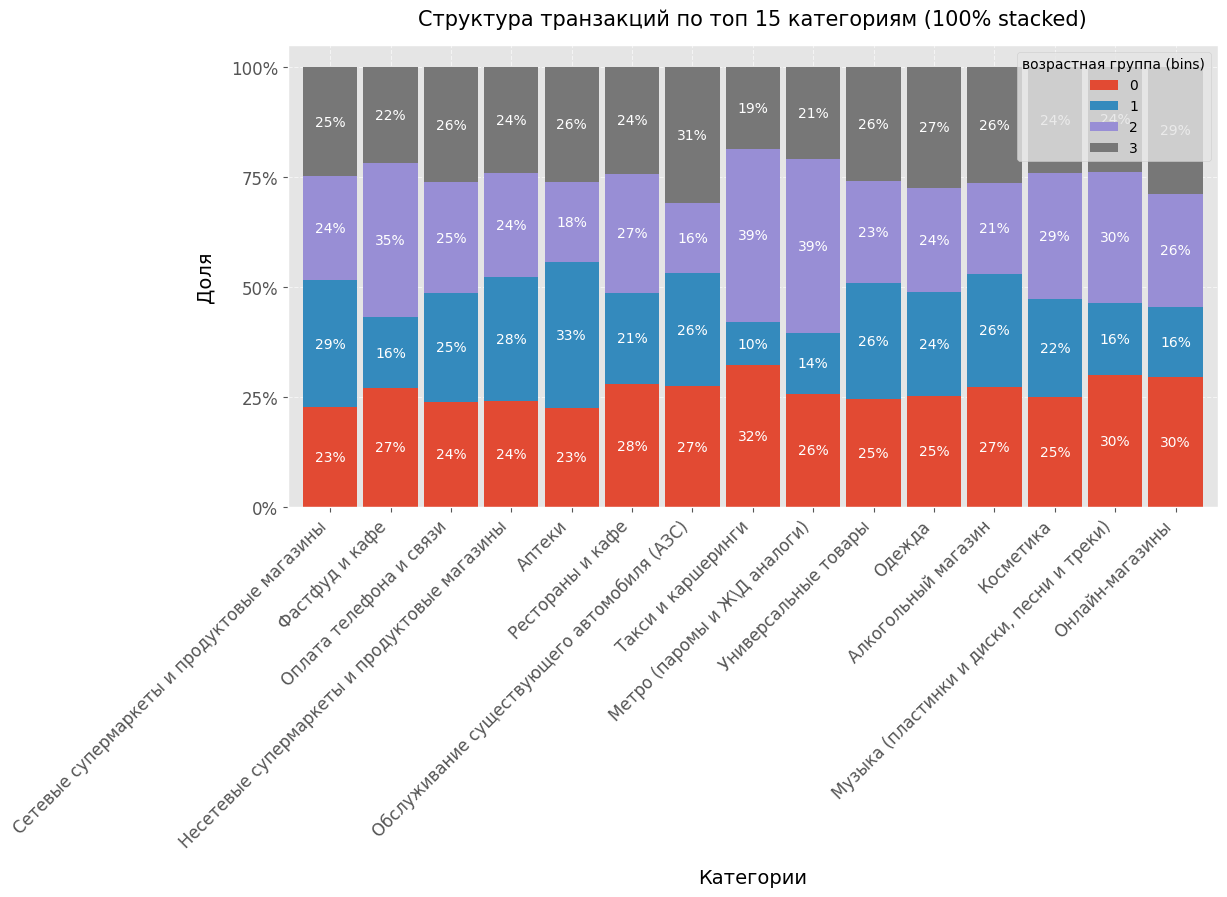

In [ ]:
stacked_bar_perc = stacked_bar.div(stacked_bar.sum(axis=1), axis=0)


plt.figure(figsize=(16, 8))

ax = stacked_bar_perc.plot(kind='bar', stacked=True, width=0.9)

for i in range(len(stacked_bar_perc)):  # по категориям (строкам)
    cumulative = 0

    for col in stacked_bar_perc.columns:  # по bins
        value = stacked_bar_perc.iloc[i][col]

        if value > 0.03:
            ax.text(
                    i,                          # позиция по X
                    cumulative + value / 2,     # центр сегмента
                    f'{value*100:.0f}%',
                    ha='center',
                    va='center',
                    fontsize=10,
                    color='white'
              )

        cumulative += value


plt.xticks(rotation=45, ha='right')
plt.yticks(ticks=[0, 0.25, 0.5, 0.75, 1], labels=['0%', '25%', '50%', '75%', '100%'])
plt.xlabel('Категории')
plt.ylabel('Доля')
plt.title('Структура транзакций по топ 15 категориям (100% stacked)')
plt.legend(title='возрастная группа (bins)')
plt.show()

На данном графике мы можем наблюдать нормированные доли возрастных групп внутри каждой категории.

ВЫбивающиеся категории:
Такси и каршеринг: группа 2 занимает 39% - аномально много
Метро и ЖД: группа 2 - 39%, тоже выброс
Аптеки: группа 3 - 26%, заметно выше чем в других категориях
Рестораны и кафе: группа 1 - 27%, группа 0 - 28%
АЗС: группа 3 - 31% -  чаще платят за автомобиль

Тут предельно видно, что отдельные категории трат действительно смещены по возрасту. Транспорт, аптеки, АЗС - потенциальные признаки для предсказания возраста.
Прямая основа для возрастного таргетинга: если клиент часто тратит на такси и метро - скорее всего группа 2. Если аптеки + АЗС - группа 3.

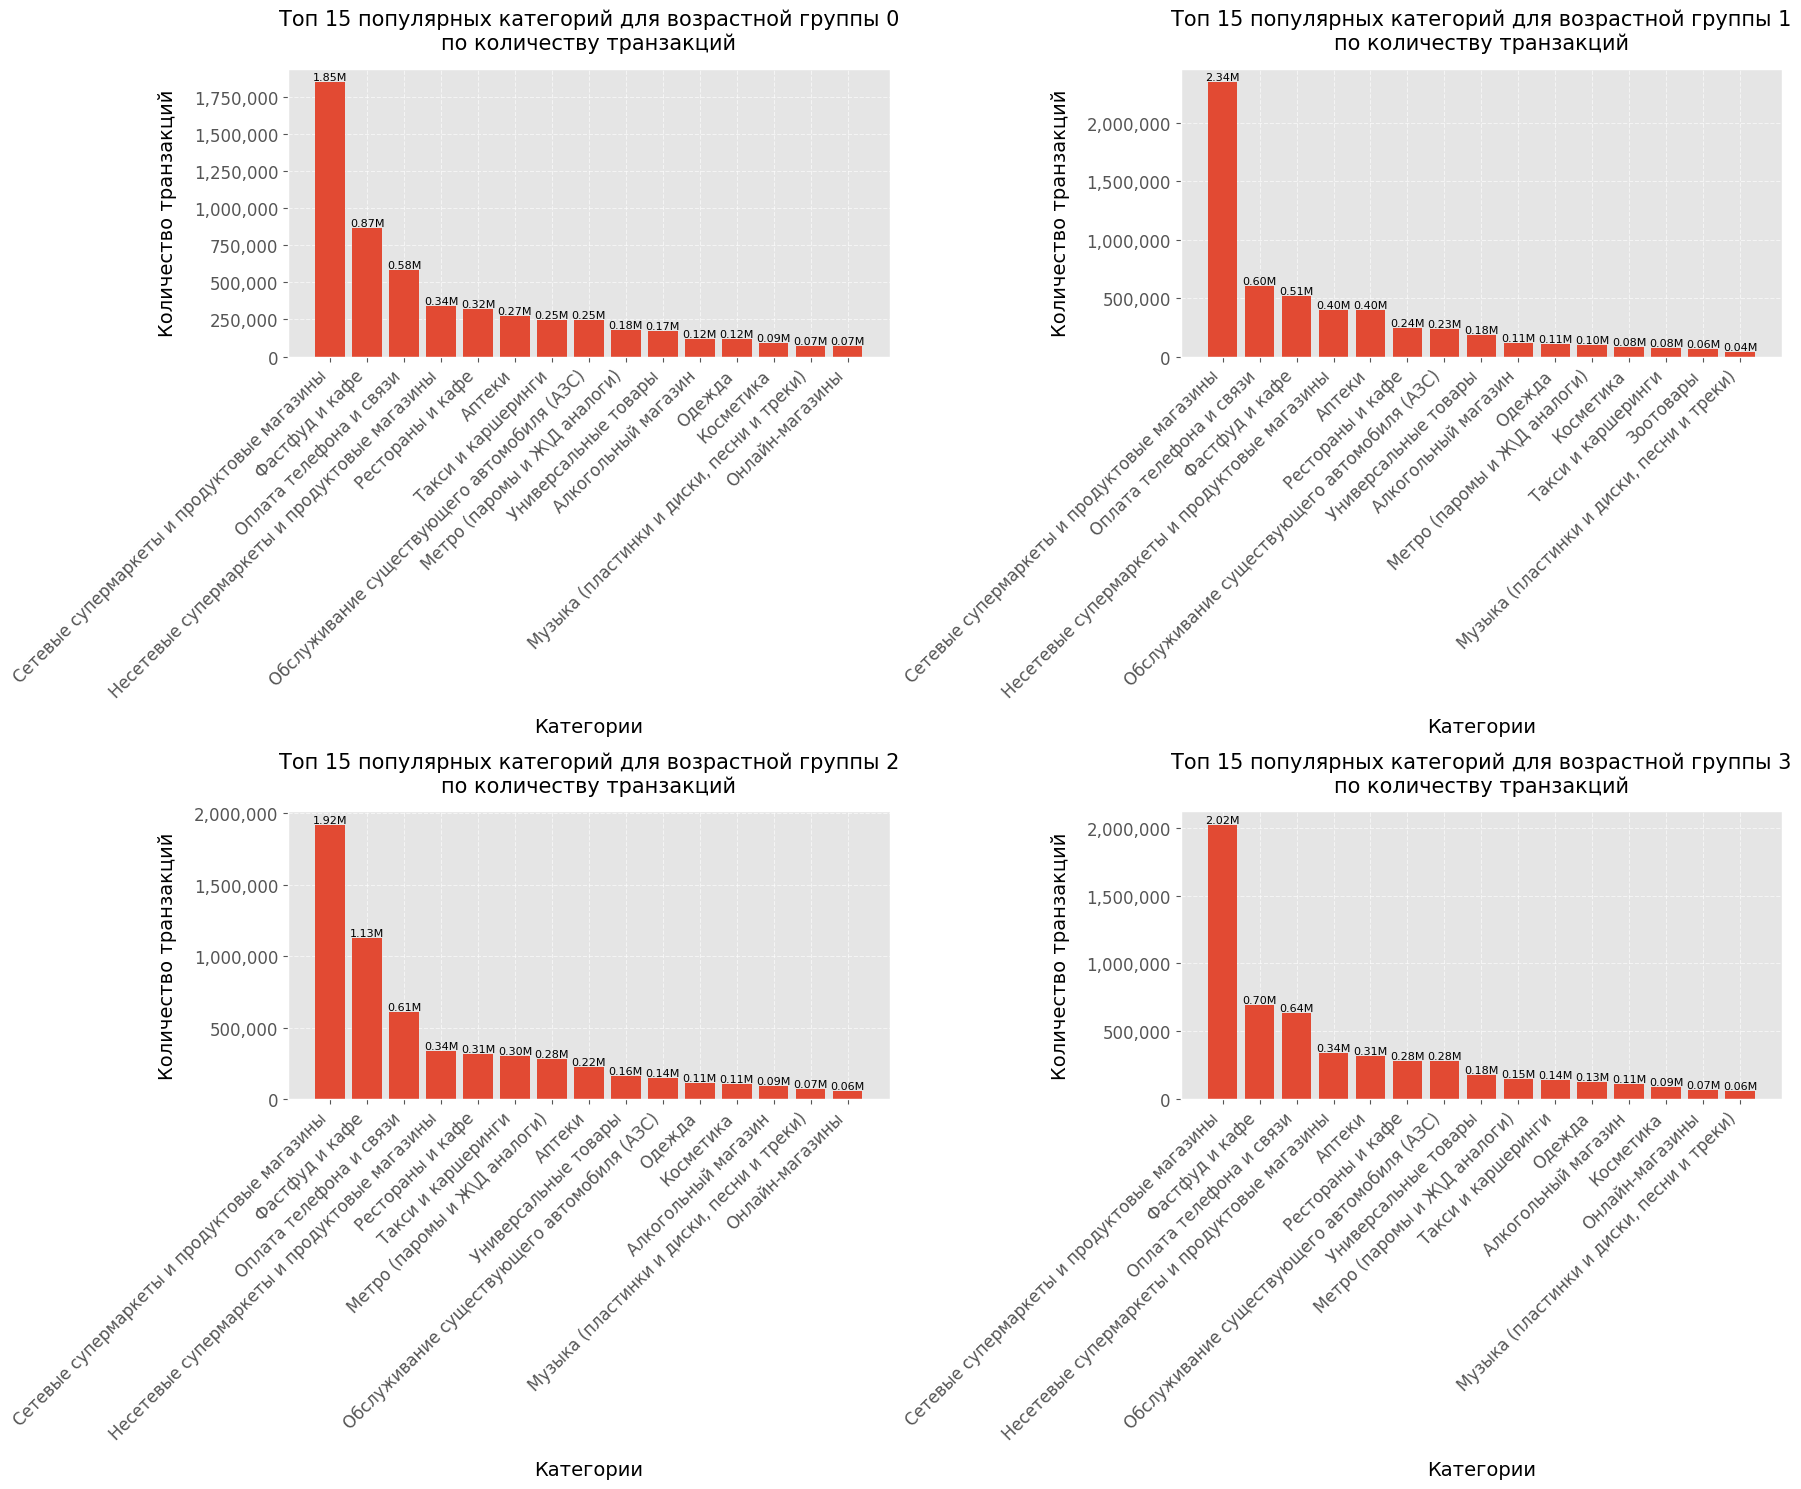

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18, 15))
axs = axs.flatten() # Flatten the 2x2 array of axes for easier iteration

for i, bin_group in enumerate(range(4)):
    current_df = df_desc[df_desc['bins'] == bin_group]
    tmp = current_df.groupby(by=['small_group']).size().sort_values(ascending=False).head(15)

    bars = axs[i].bar(tmp.index, tmp.values, width=0.8) # Plot on the current ax

    for bar in bars:
        height = bar.get_height()
        axs[i].text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height/1_000_000:.2f}M',
            ha='center', va='bottom', fontsize = 8
        )

    axs[i].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    axs[i].set_xlabel('Категории')
    axs[i].set_ylabel('Количество транзакций')
    axs[i].set_xticklabels(tmp.index, rotation=45, ha='right')

    axs[i].set_title(f'Топ 15 популярных категорий для возрастной группы {bin_group}\nпо количеству транзакций')

plt.tight_layout()
plt.show()

Первые 15 популярные категории по количеству транзакицй особо не отличаются среди всех возрастных групп.

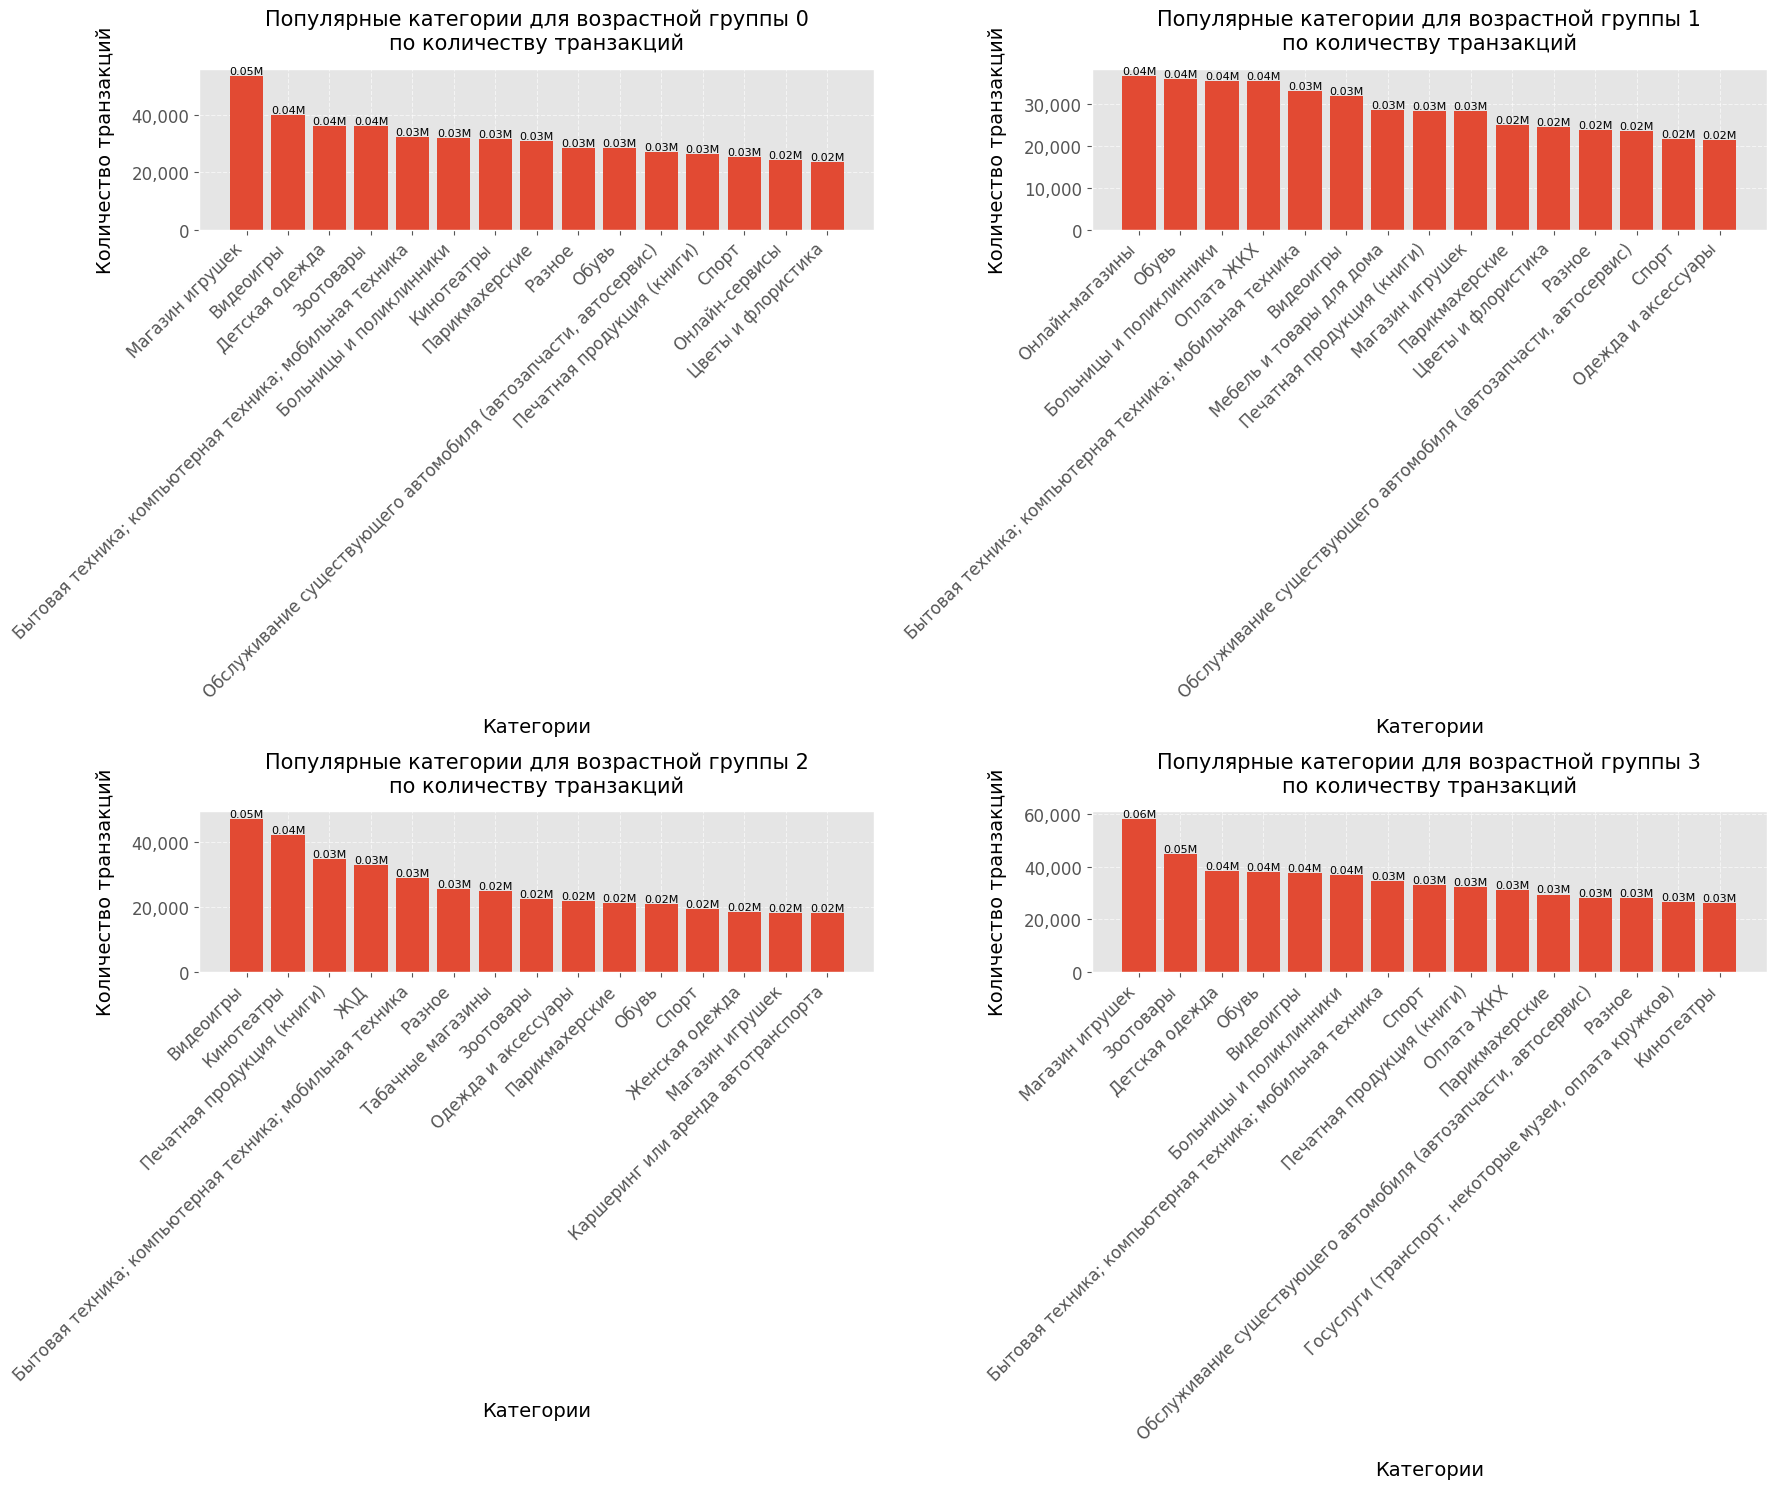

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18, 15))
axs = axs.flatten() # Flatten the 2x2 array of axes for easier iteration

for i, bin_group in enumerate(range(4)):
    current_df = df_desc[df_desc['bins'] == bin_group]
    tmp = current_df.groupby(by=['small_group']).size().sort_values(ascending=False).iloc[15:30:]

    bars = axs[i].bar(tmp.index, tmp.values, width=0.8) # Plot on the current ax

    for bar in bars:
        height = bar.get_height()
        axs[i].text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height/1_000_000:.2f}M',
            ha='center', va='bottom', fontsize = 8
        )

    axs[i].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    axs[i].set_xlabel('Категории')
    axs[i].set_ylabel('Количество транзакций')
    axs[i].set_xticklabels(tmp.index, rotation=45, ha='right')

    axs[i].set_title(f'Популярные категории для возрастной группы {bin_group}\nпо количеству транзакций')

plt.tight_layout()
plt.show()

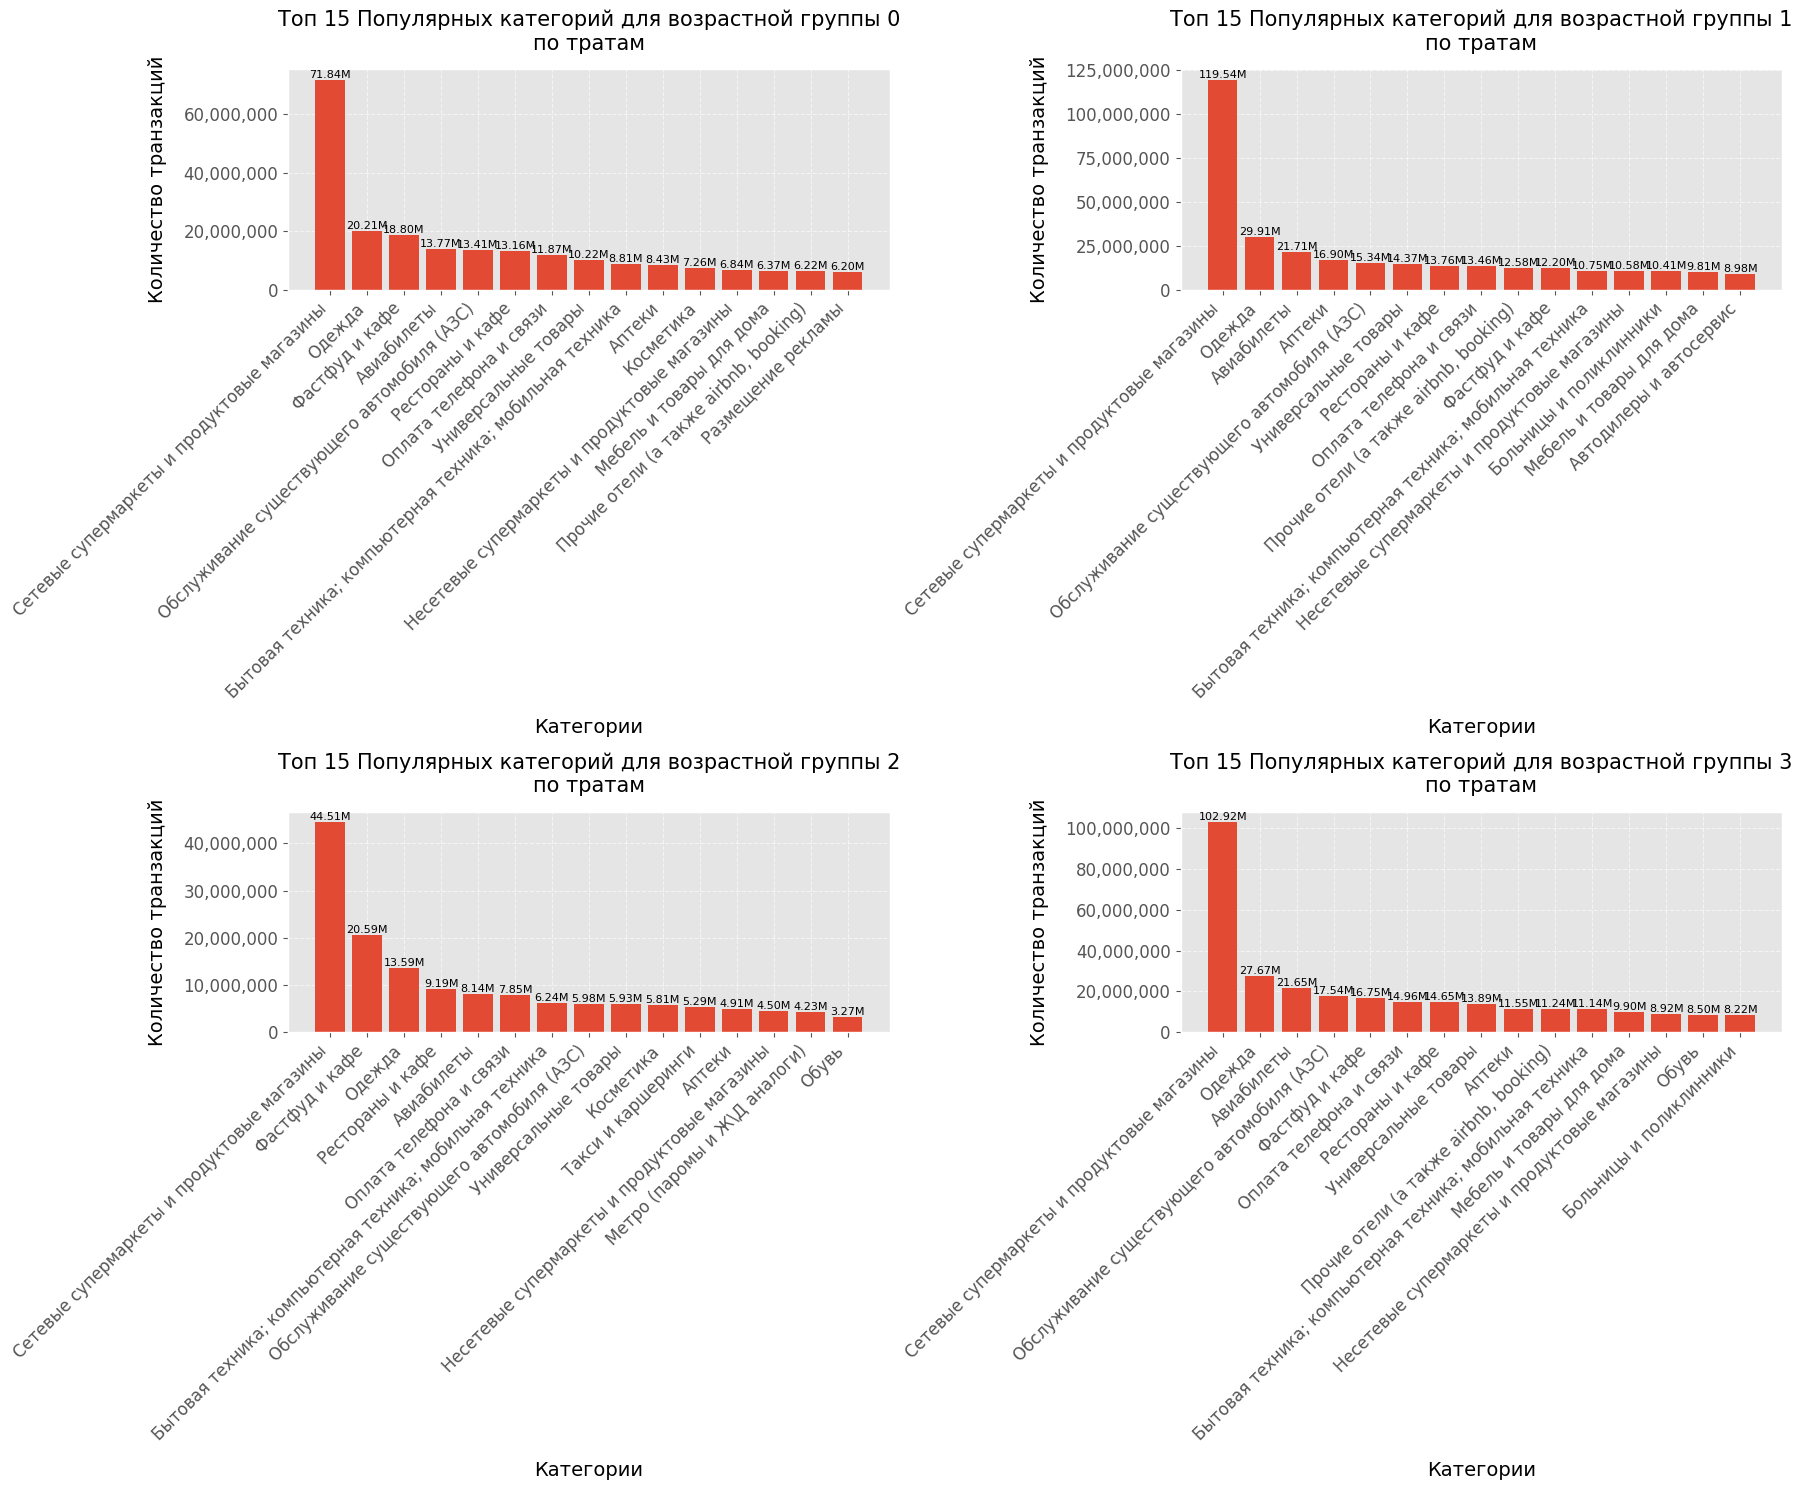

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18, 15))
axs = axs.flatten() # Flatten the 2x2 array of axes for easier iteration

for i, bin_group in enumerate(range(4)):
    current_df = df_desc[df_desc['bins'] == bin_group]
    tmp = current_df.groupby(by=['small_group'])['amount_rur'].sum().sort_values(ascending=False).head(15)

    bars = axs[i].bar(tmp.index, tmp.values, width=0.8) # Plot on the current ax

    for bar in bars:
        height = bar.get_height()
        axs[i].text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height/1_000_000:.2f}M',
            ha='center', va='bottom', fontsize = 8
        )

    axs[i].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    axs[i].set_xlabel('Категории')
    axs[i].set_ylabel('Количество транзакций')
    axs[i].set_xticklabels(tmp.index, rotation=45, ha='right')

    axs[i].set_title(f'Топ 15 Популярных категорий для возрастной группы {bin_group}\nпо тратам')

plt.tight_layout()
plt.show()

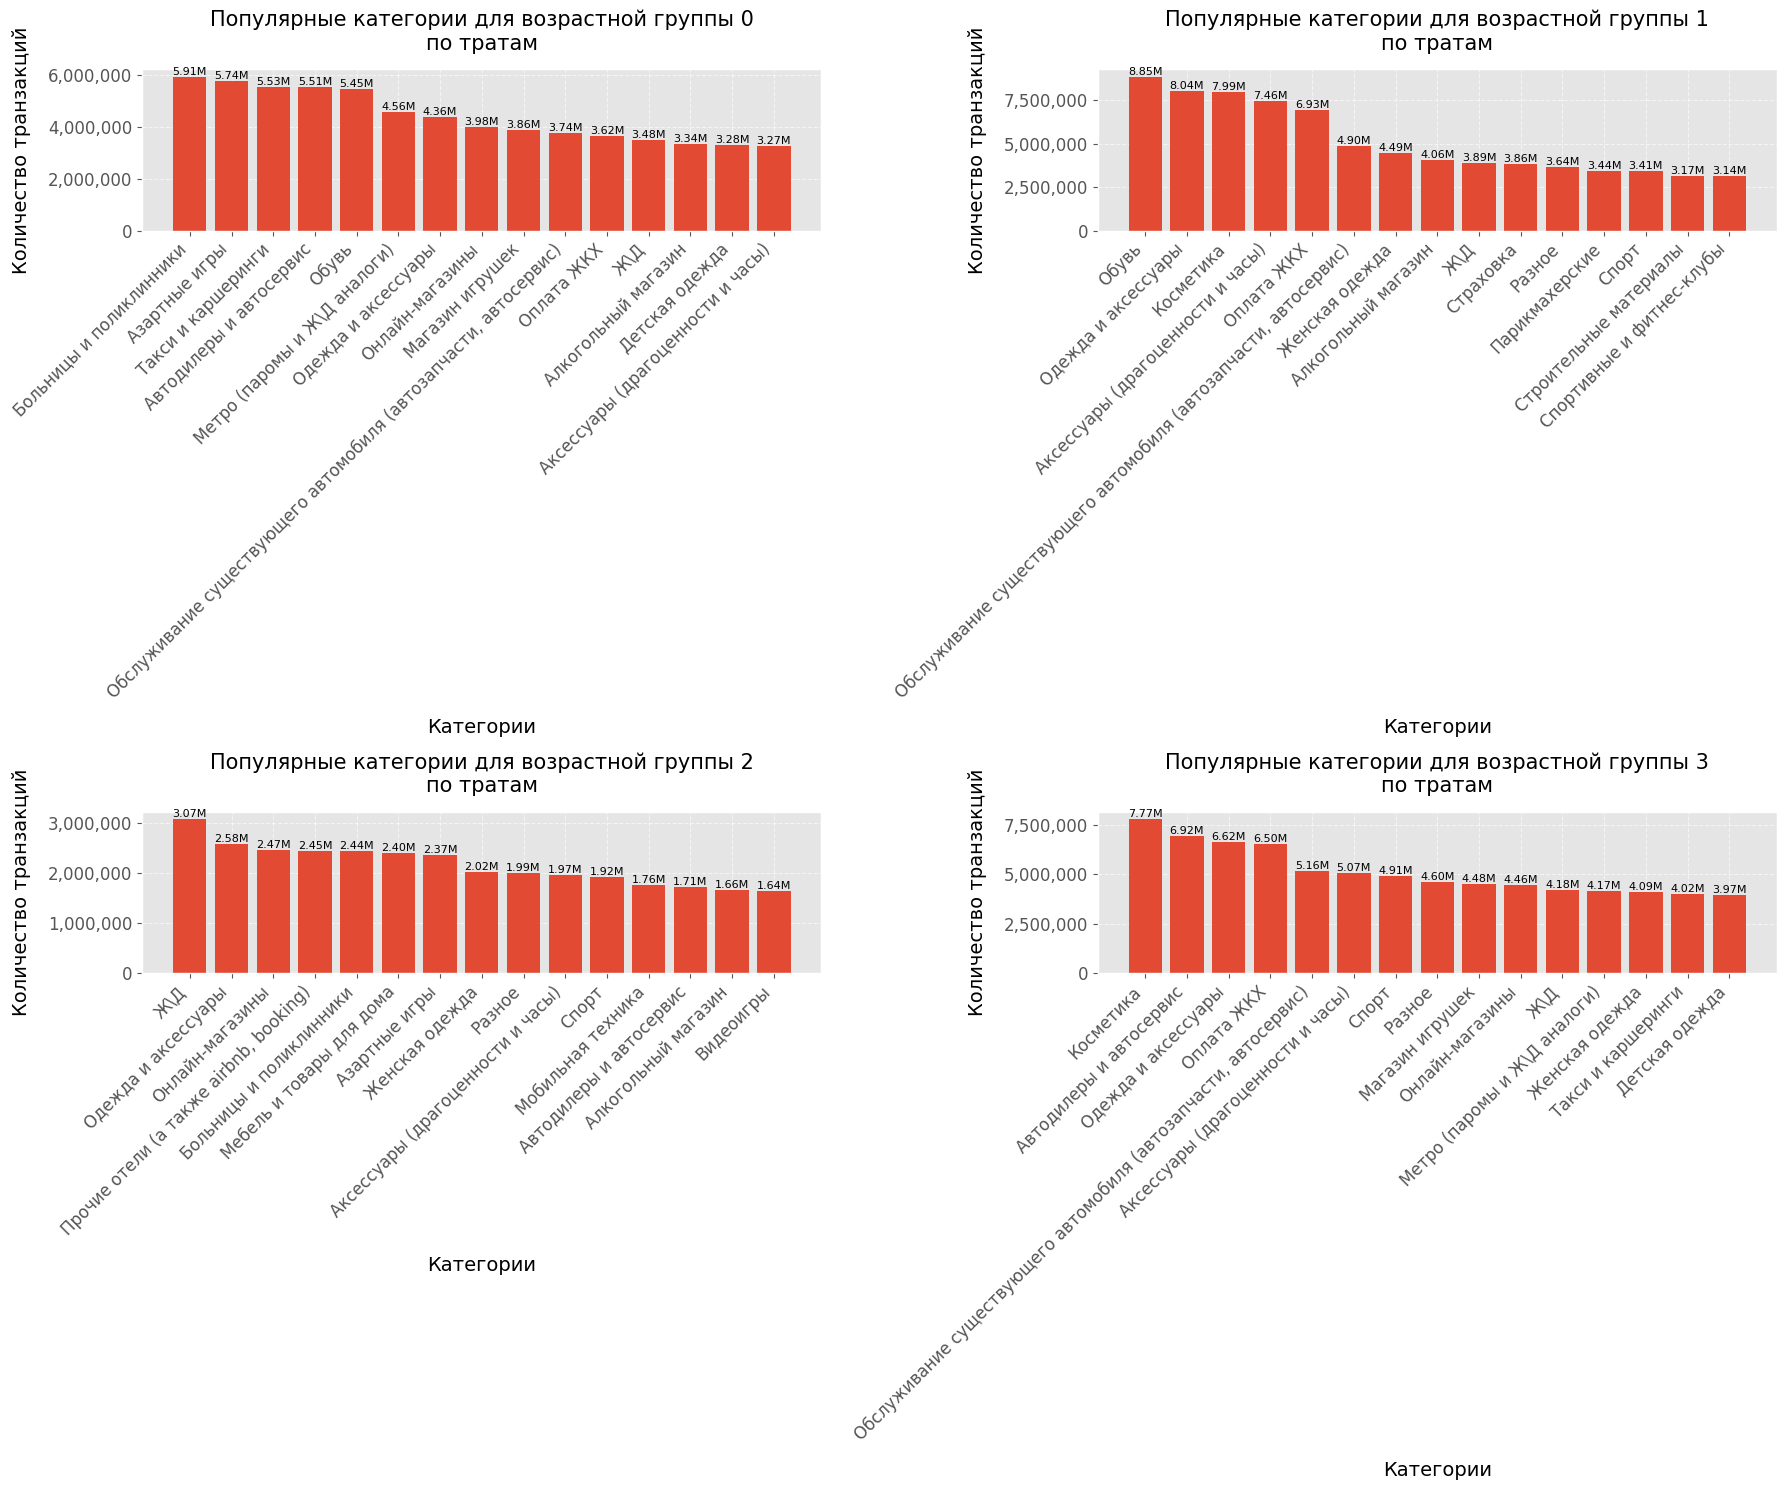

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18, 15))
axs = axs.flatten() # Flatten the 2x2 array of axes for easier iteration

for i, bin_group in enumerate(range(4)):
    current_df = df_desc[df_desc['bins'] == bin_group]
    tmp = current_df.groupby(by=['small_group'])['amount_rur'].sum().sort_values(ascending=False).iloc[15:30:]

    bars = axs[i].bar(tmp.index, tmp.values, width=0.8) # Plot on the current ax

    for bar in bars:
        height = bar.get_height()
        axs[i].text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height/1_000_000:.2f}M',
            ha='center', va='bottom', fontsize = 8
        )

    axs[i].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    axs[i].set_xlabel('Категории')
    axs[i].set_ylabel('Количество транзакций')
    axs[i].set_xticklabels(tmp.index, rotation=45, ha='right')

    axs[i].set_title(f'Популярные категории для возрастной группы {bin_group}\nпо тратам')

plt.tight_layout()
plt.show()

In [ ]:
unique_clients_per_bin = df_desc.groupby('bins')['client_id'].nunique().reset_index()
print('Количество уникальных клиентов по возрастным группам:')
display(unique_clients_per_bin)

Количество уникальных клиентов по возрастным группам:


,bins,client_id
0,0,7434
1,1,7497
2,2,7560
3,3,7509


In [ ]:
expected = df_desc.groupby('bins').size() / len(df_desc)
print("Доля каждой группы в базе:")
print(expected.round(2))

cat_group = (df_desc
             .groupby(['small_group', 'bins'])
             .size()
             .unstack(fill_value=0))


cat_group = cat_group[cat_group.sum(axis=1) >= 5000]

actual_share = cat_group.div(cat_group.sum(axis=1), axis=0)

lift = actual_share.div(expected)


Доля каждой группы в базе:
bins
0    0.25
1    0.24
2    0.25
3    0.25
dtype: float64


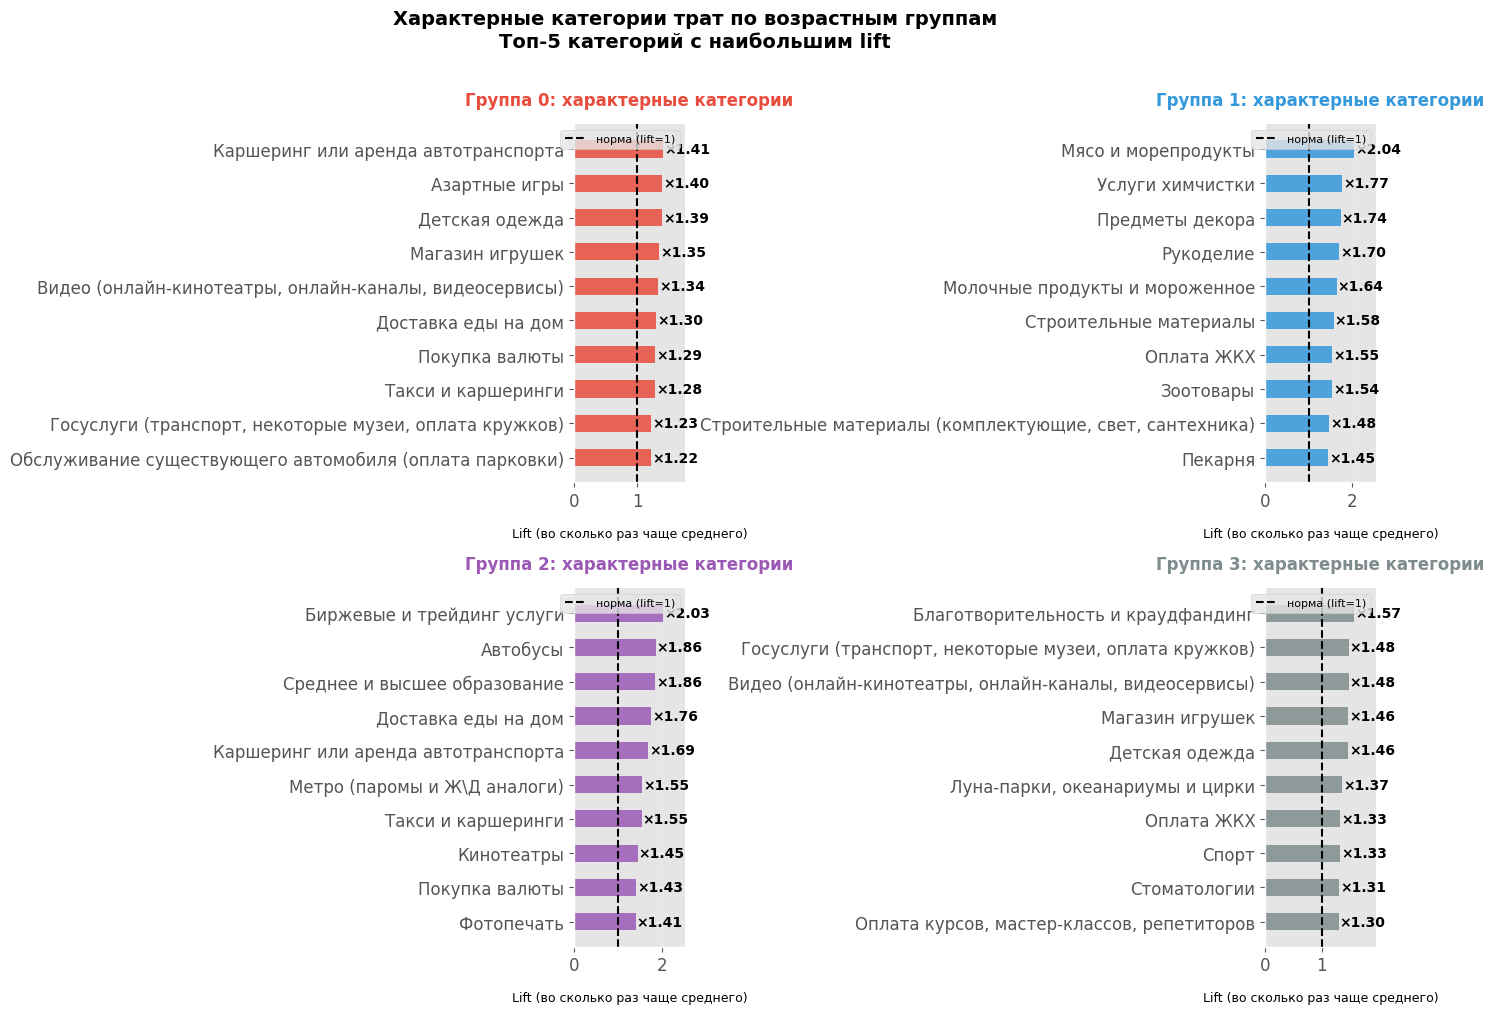

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#e74c3c', '#3498db', '#9b59b6', '#7f8c8d']
group_names = ['Группа 0', 'Группа 1', 'Группа 2', 'Группа 3']

for i, grp in enumerate(sorted(lift.columns)):
    ax = axes[i]

    top5 = lift[grp].nlargest(10).sort_values(ascending=True)

    bars = ax.barh(top5.index, top5.values,
                   color=colors[i], alpha=0.85, height=0.5)

    ax.axvline(1.0, color='black', linewidth=1.5,
               linestyle='--', label='норма (lift=1)')


    for bar, val in zip(bars, top5.values):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'×{val:.2f}', va='center', fontsize=10, fontweight='bold')

    ax.set_title(f'{group_names[i]}: характерные категории',
                 fontsize=12, fontweight='bold', color=colors[i])
    ax.set_xlabel('Lift (во сколько раз чаще среднего)', fontsize=9)
    ax.set_xlim(0, top5.max() * 1.25)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle=':')
    ax.legend(fontsize=8)

plt.suptitle('Характерные категории трат по возрастным группам\n'
             'Топ-5 категорий с наибольшим lift',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# **Анализ сумм транзакций**

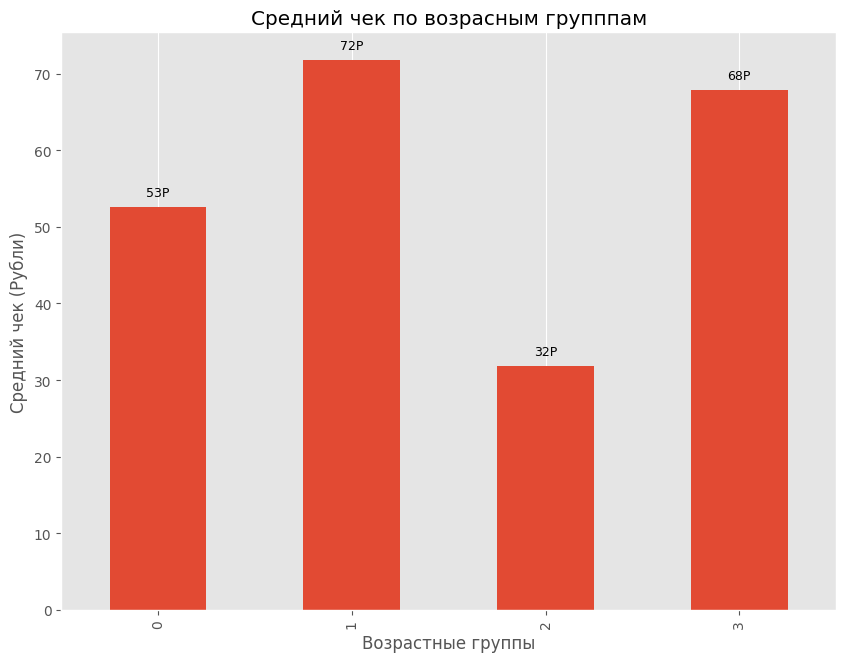

In [ ]:
plt.figure()

avg_by_bins = df_trans.groupby(by='bins')['amount_rur'].mean()

ax = avg_by_bins.plot(kind='bar')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:,.0f}Р',
        ha='center', va='bottom',
        fontsize=9
    )

plt.title('Средний чек по возрасным групппам') # кто тратит больше за раз
plt.xlabel('Возрастные группы')
plt.ylabel('Средний чек (Рубли)')
plt.grid(axis='y')
plt.show()

Группы 1 и 3 самые доходо-обеспеченные

In [ ]:
df_desc.head()

,client_id,trans_date,small_group_x,amount_rur,bins,dayofweek,small_group,small_group_code
0,4,0,1,10.209,1,4,Сетевые супермаркеты и продуктовые магазины,1
1,4,2,3,27.706,1,6,Оплата телефона и связи,3
2,4,3,1,13.024,1,0,Сетевые супермаркеты и продуктовые магазины,1
3,4,4,1,17.632,1,1,Сетевые супермаркеты и продуктовые магазины,1
4,4,6,4,18.089,1,3,Аптеки,4


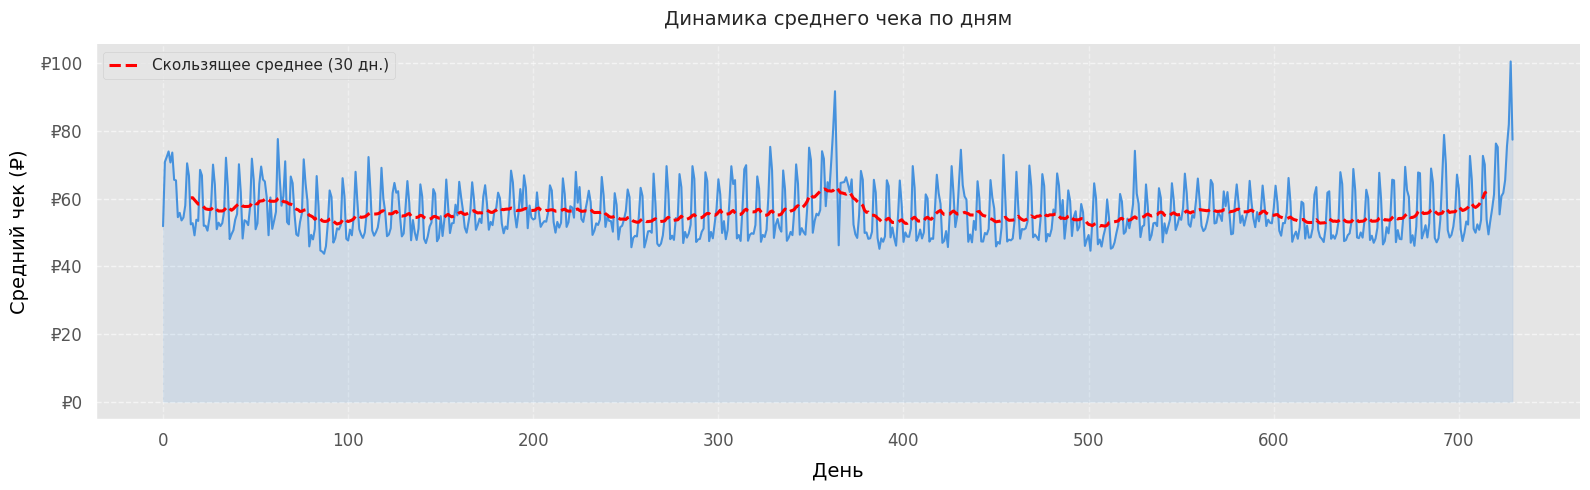

In [ ]:
avg_by_day = df_trans.groupby('trans_date')['amount_rur'].mean()

plt.figure(figsize=(16, 5))

plt.plot(avg_by_day.index, avg_by_day.values,
         color='#378ADD', linewidth=1.5, alpha=0.9)

plt.fill_between(avg_by_day.index, avg_by_day.values,
                 alpha=0.12, color='#378ADD')

rolling = avg_by_day.rolling(window=30, center=True).mean()
plt.plot(rolling.index, rolling.values,
         color='red', linewidth=2.2,
         linestyle='--', label='Скользящее среднее (30 дн.)')

plt.title('Динамика среднего чека по дням', fontsize=14, pad=14)
plt.xlabel('День', labelpad=8)
plt.ylabel('Средний чек (₽)', labelpad=8)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'₽{x:,.0f}'
))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('avg_check_by_day.png', dpi=150)
plt.show()

Данный граффик это динамика среднего чека по дня ровно за 2 года. Можно заметить, что средний чек стабилен (~50-65 руб.) на протяжении всего периода, скользящее среднее (красная линия) практически горизонтально. Есть периодические пики - скорее всего выходные или праздники (скорее всего новый год).
Стабильность среднего чека во времени означает, что временной тренд не искажает данные - можно сравнивать возрастные группы без поправки на время.
Отсутствие роста среднего чека при росте суммы (график "Сумма денег по дням") означает, что растёт количество транзакций или клиентов, а не размер покупки - важный вывод для стратегии.

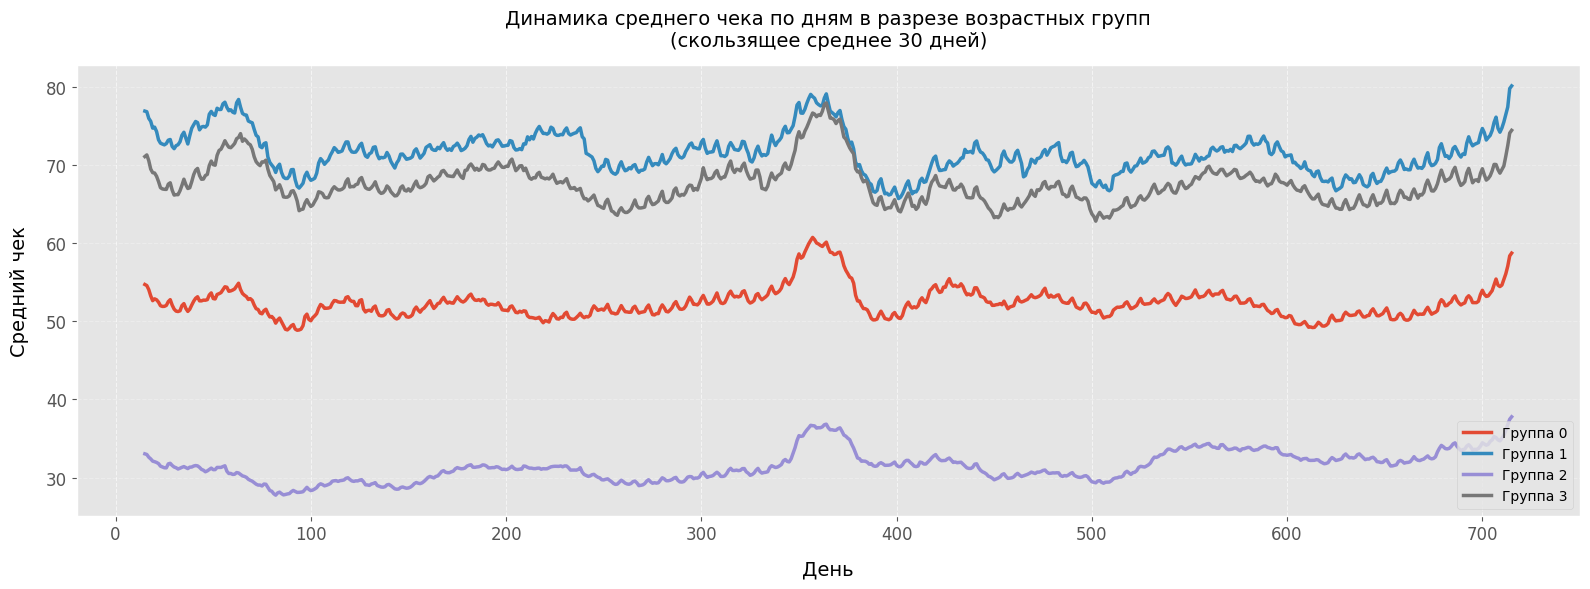

In [ ]:
plt.figure(figsize=(16, 6))

for group in sorted(df_desc['bins'].unique()):
    group_df = (
        df_desc[df_desc['bins'] == group]
        .groupby('trans_date')['amount_rur']
        .mean()
        .reset_index()
        .sort_values('trans_date')
    )

    rolling = group_df['amount_rur'].rolling(window=30, center=True).mean()

    plt.plot(
        group_df['trans_date'],
        rolling,
        linewidth=2.5,
        label=f'Группа {group}'
    )

plt.title('Динамика среднего чека по дням в разрезе возрастных групп\n(скользящее среднее 30 дней)', fontsize=14)
plt.xlabel('День')
plt.ylabel('Средний чек')
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Этот показывает четыре линии чётко разделены и не пересекаются на протяжении всего периода. Группа 1 (синяя) стабильно лидирует (~75 руб.), группа 3 (фиолетовая) - рядом (~70 руб.), группа 0 (красная) - средне (~52 руб.), группа 2 (сиреневая) - аномально низко (~30 руб.) и держится там постоянно. Средний чек стабильно различается между группами на протяжении 730 дней - это не случайность, а устойчивая поведенческая характеристика. Значит, размер чека - потенциально хороший признак для предсказания возраста. Группа 2 платит вдвое меньше группы 1  - это контринтуитивно. группа 2 доминирует в каких-то специфических дешёвых категориях.

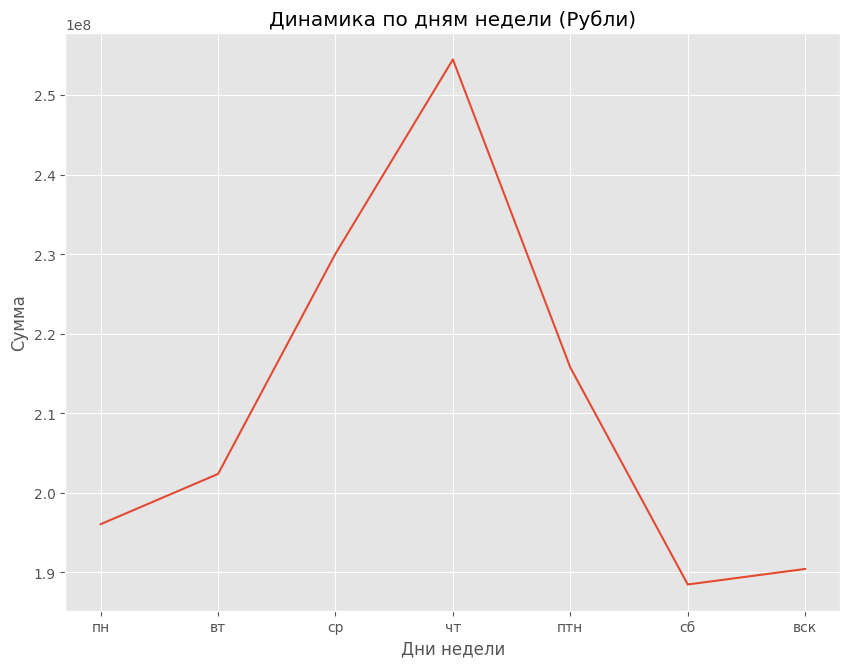

In [ ]:
amount_by_days = df_trans.groupby(by=['dayofweek'])['amount_rur'].sum()

plt.figure()

plt.plot(amount_by_days.index, amount_by_days.values)

plt.title('Динамика по дням недели (Рубли)')
plt.xlabel('Дни недели')
plt.ylabel('Сумма')
plt.xticks(ticks = np.arange(7), labels = ['пн', 'вт', 'ср', 'чт', 'птн', 'сб', 'вск'])
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

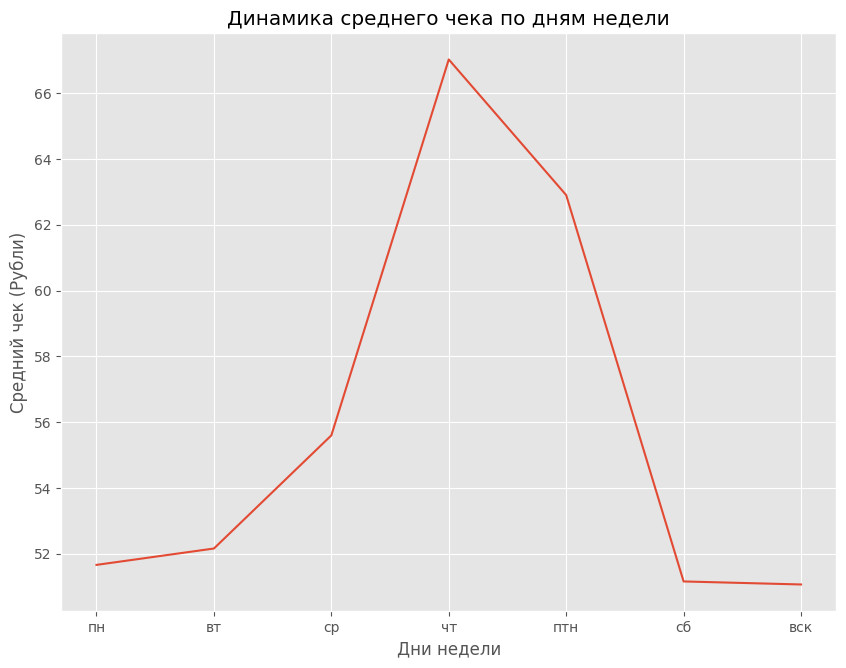

In [ ]:
# средний чек по дням недели
avg_dayofweek = df_trans.groupby(by=['dayofweek'])['amount_rur'].mean()

plt.figure()

plt.plot(avg_dayofweek.index, avg_dayofweek.values)

plt.title('Динамика среднего чека по дням недели')
plt.xlabel('Дни недели')
plt.ylabel('Средний чек (Рубли)')
plt.xticks(ticks=np.arange(7), labels=['пн', 'вт', 'ср', 'чт', 'птн', 'сб', 'вск'])
plt.show()

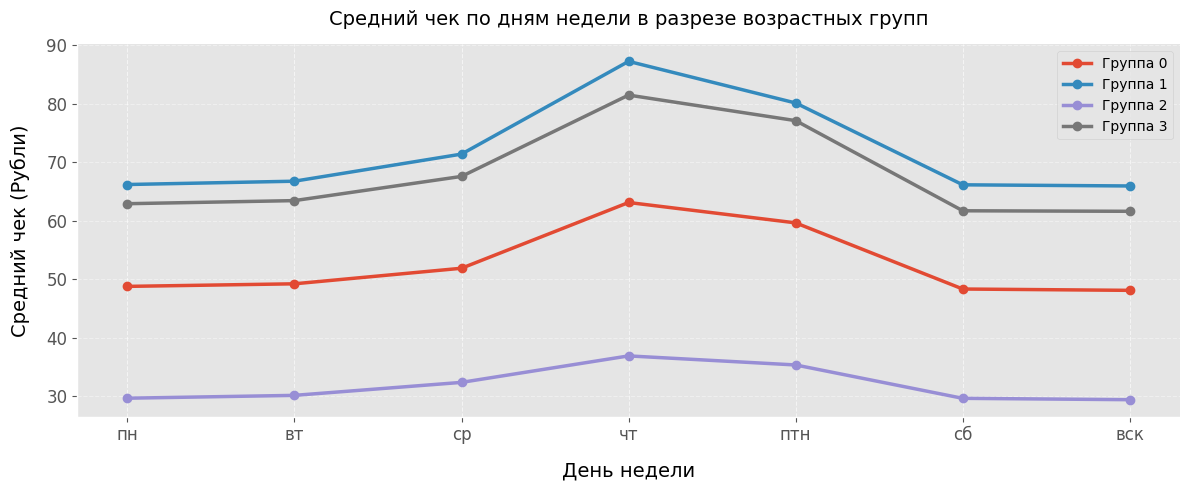

In [ ]:
days_order = ['пн', 'вт', 'ср', 'чт', 'птн', 'сб', 'вск']
day_map = {0: 'пн', 1: 'вт', 2: 'ср', 3: 'чт', 4: 'птн', 5: 'сб', 6: 'вск'}

df_trans['day_name'] = df_trans['dayofweek'].map(day_map)

plt.figure(figsize=(12, 5))

for group in sorted(df_trans['bins'].unique()):
    group_df = (
        df_trans[df_trans['bins'] == group]
        .groupby('day_name')['amount_rur']
        .mean()
        .reindex(days_order)
    )
    plt.plot(days_order, group_df.values, linewidth=2.5, marker='o', label=f'Группа {group}')

plt.title('Средний чек по дням недели в разрезе возрастных групп', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Средний чек (Рубли)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

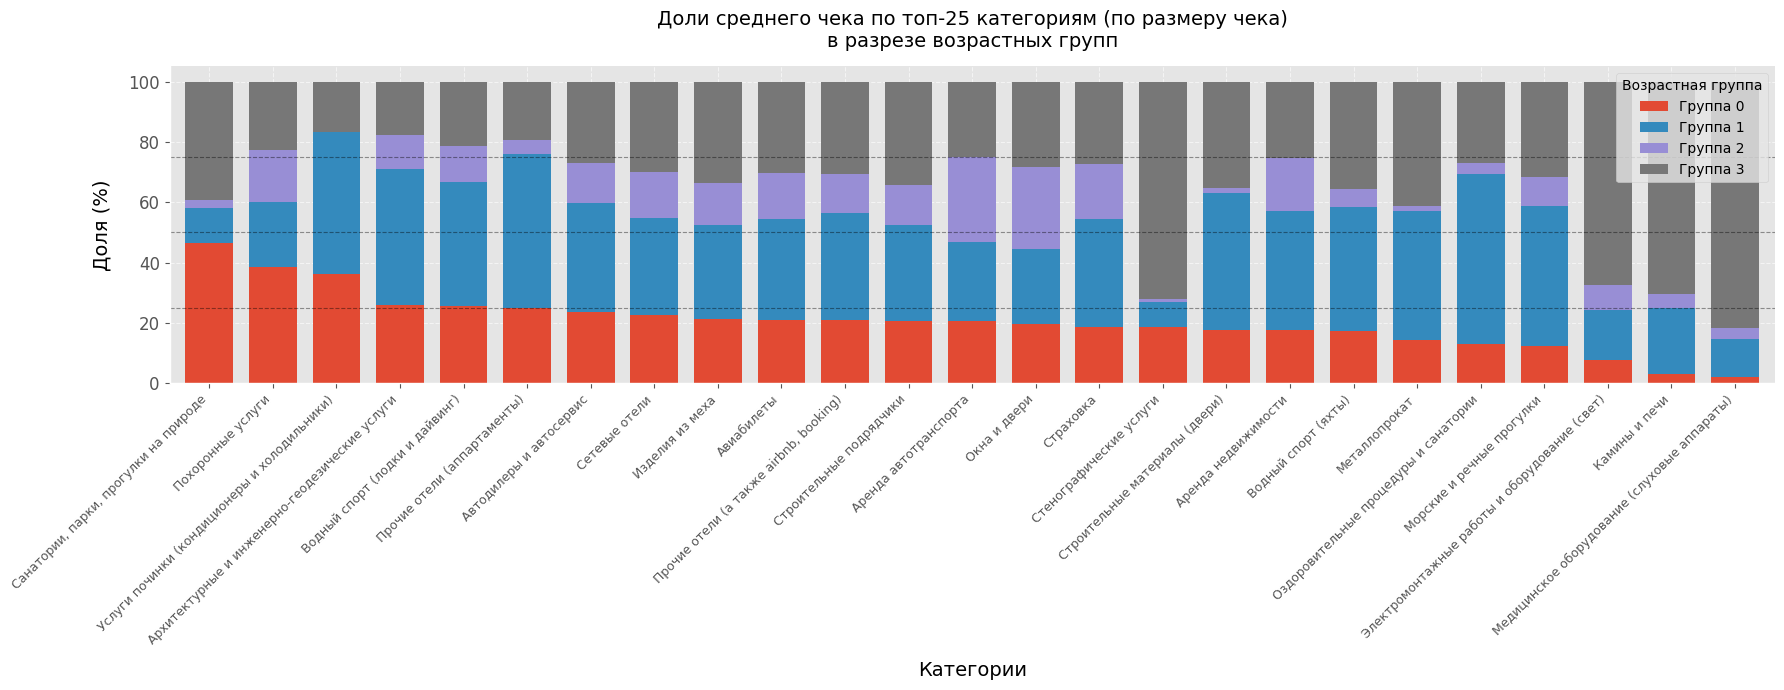

In [ ]:
top_categories = (
    df_desc.groupby('small_group')['amount_rur']
    .mean()
    .sort_values(ascending=False)
    .head(25)
    .index.tolist()
)


pivot = (
    df_desc[df_desc['small_group'].isin(top_categories)]
    .groupby(['small_group', 'bins'])['amount_rur']
    .mean()
    .unstack('bins')
)


pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct = pivot_pct.sort_values(by=0, ascending=False)


pivot_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(18, 7),
    width=0.75
)

plt.title('Доли среднего чека по топ-25 категориям (по размеру чека)\nв разрезе возрастных групп', fontsize=14)
plt.xlabel('Категории', labelpad=10)
plt.ylabel('Доля (%)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.legend(title='Возрастная группа', labels=[f'Группа {i}' for i in range(4)])
plt.axhline(y=25, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
plt.axhline(y=50, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
plt.axhline(y=75, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

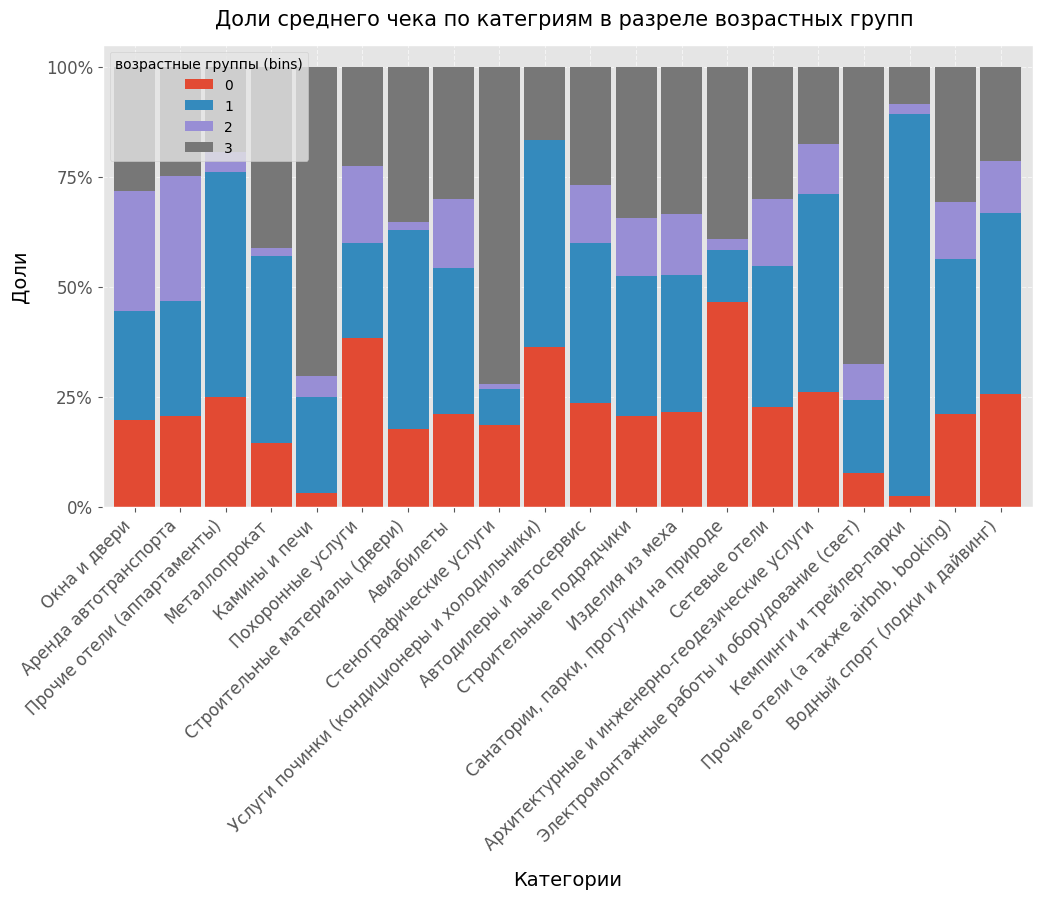

In [ ]:
avg_perc = avg_bins.div(avg_bins.sum(axis=1), axis=0).head(20)

avg_perc.plot(kind='bar', stacked=True, width=0.8)

for i in range(len(stacked_bar_perc)):  # по категориям (строкам)
    cumulative = 0

    for col in stacked_bar_perc.columns:  # по bins
        value = stacked_bar_perc.iloc[i][col]

        if value > 0.03:
            ax.text(
                    i,                          # позиция по X
                    cumulative + value / 2,     # центр сегмента
                    f'{value*100:.0f}%',
                    ha='center',
                    va='center',
                    fontsize=10,
                    color='white'
              )

        cumulative += value


plt.title('Доли среднего чека по категриям в разрезе возрастных групп ')
plt.xlabel('Категории')
plt.ylabel('Доли')
plt.xticks(rotation=45, ha='right')
plt.yticks(ticks=[0, 0.25, 0.5, 0.75, 1], labels=['0%', '25%', '50%', '75%', '100%'])
plt.legend(title='возрастные группы (bins)')
plt.show()

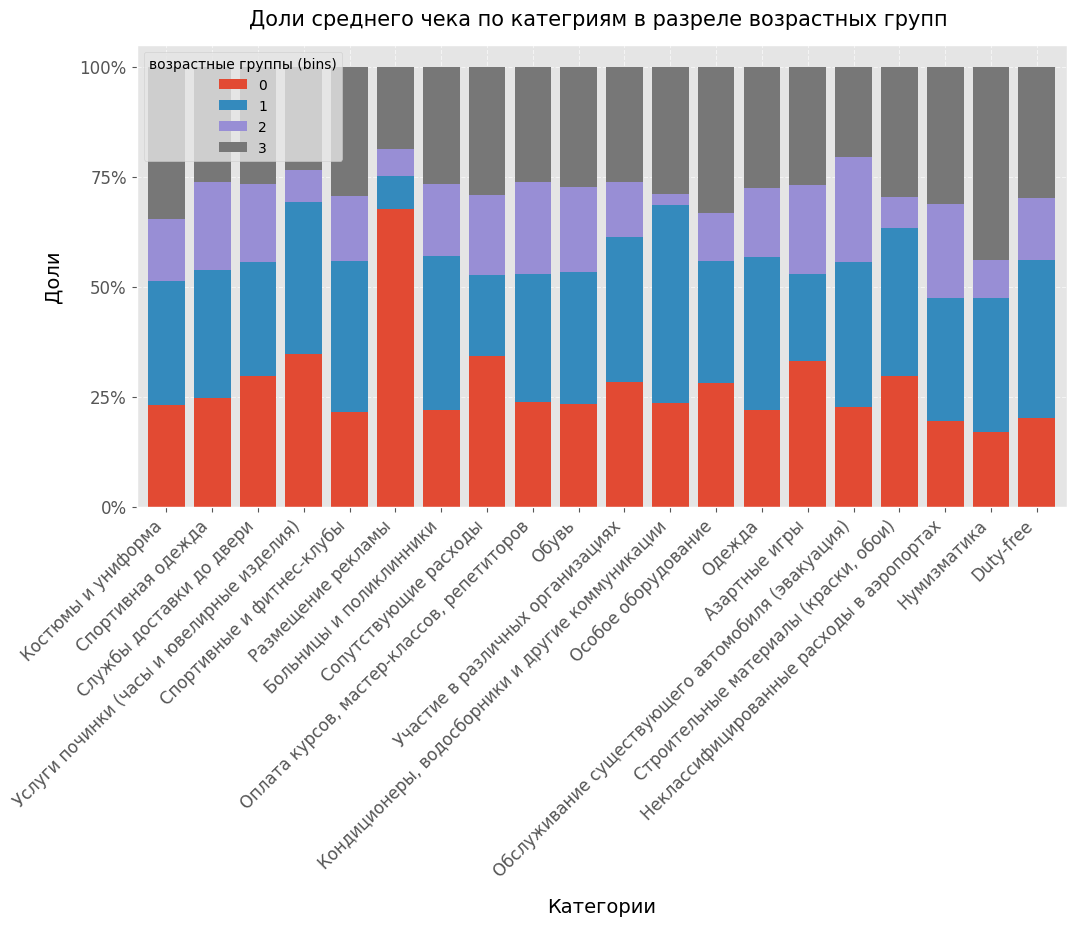

In [ ]:
avg_perc = avg_bins.div(avg_bins.sum(axis=1), axis=0).iloc[60:80, :]

avg_perc.plot(kind='bar', stacked=True, width=0.8)

for i in range(len(stacked_bar_perc)):  # по категориям (строкам)
    cumulative = 0

    for col in stacked_bar_perc.columns:  # по bins
        value = stacked_bar_perc.iloc[i][col]

        if value > 0.03:
            ax.text(
                    i,                          # позиция по X
                    cumulative + value / 2,     # центр сегмента
                    f'{value*100:.0f}%',
                    ha='center',
                    va='center',
                    fontsize=10,
                    color='white'
              )

        cumulative += value


plt.title('Доли среднего чека по категриям в разреле возрастных групп ')
plt.xlabel('Категории')
plt.ylabel('Доли')
plt.xticks(rotation=45, ha='right')
plt.yticks(ticks=[0, 0.25, 0.5, 0.75, 1], labels=['0%', '25%', '50%', '75%', '100%'])
plt.legend(title='возрастные группы (bins)')
plt.show()

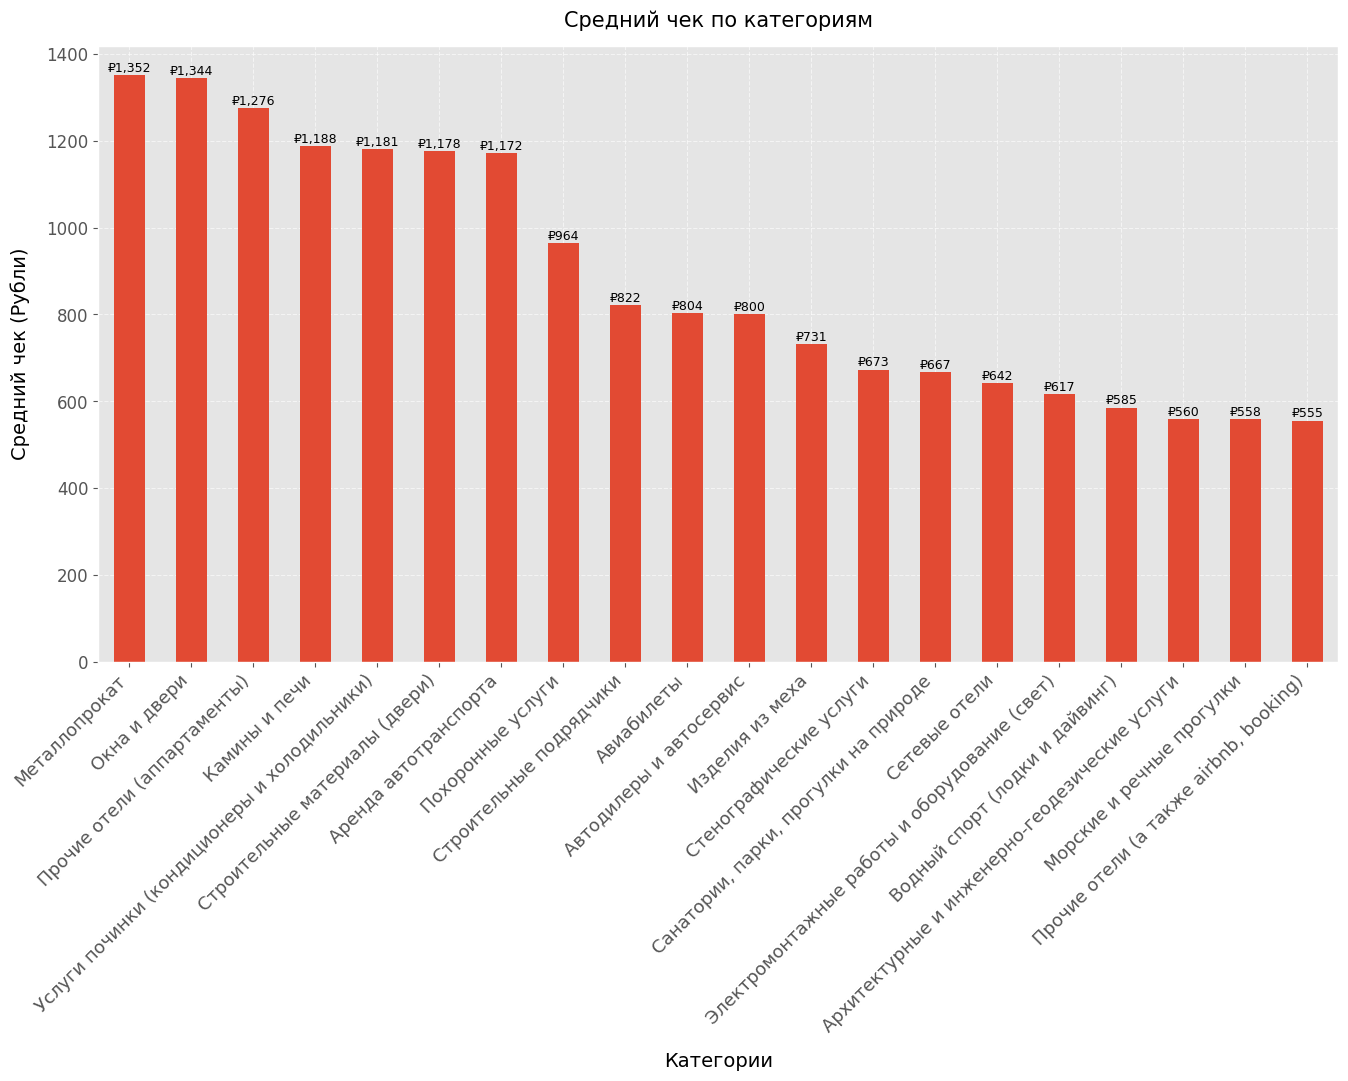

In [ ]:
plt.figure(figsize=(16, 8))
avg_groups = df_desc.groupby(by=['small_group'])['amount_rur'].mean().sort_values(ascending=False).head(20)

ax = avg_groups.plot(kind='bar')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'₽{height:,.0f}',
        ha='center', va='bottom',
        fontsize=9
    )

plt.title('Средний чек по топ 20 категориям')
plt.ylabel('Средний чек (Рубли)')
plt.xlabel('Категории')
plt.xticks(rotation=45, ha='right', fontsize=13)
plt.show()

Данный график показывает совершенно другой рейтинг категорий. Металлопрокат (1352 руб.), окна и двери (1344 руб.), апартаменты (1276 руб.) — категории с редкими но крупными платежами, которых не было в топе по количеству транзакций.
Два рейтинга вместе дают полную картину: частые мелкие платежи (супермаркеты, фастфуд) vs редкие крупные (ремонт, аренда, авиа). Возрастные группы могут по-разному распределяться между этими типами — это прямой ответ на главный вопрос.

In [ ]:
df_desc['amount_rur'].max() / df_desc['amount_rur'].median()


20123.06558696308

In [ ]:
df_desc.head()


,client_id,trans_date,amount_rur,bins,dayofweek,small_group,small_group_code
0,4,0,10.209,1,4,Сетевые супермаркеты и продуктовые магазины,1
1,4,2,27.706,1,6,Оплата телефона и связи,3
2,4,3,13.024,1,0,Сетевые супермаркеты и продуктовые магазины,1
3,4,4,17.632,1,1,Сетевые супермаркеты и продуктовые магазины,1
4,4,6,18.089,1,3,Аптеки,4


**Динамика по дням недели Х возраст**

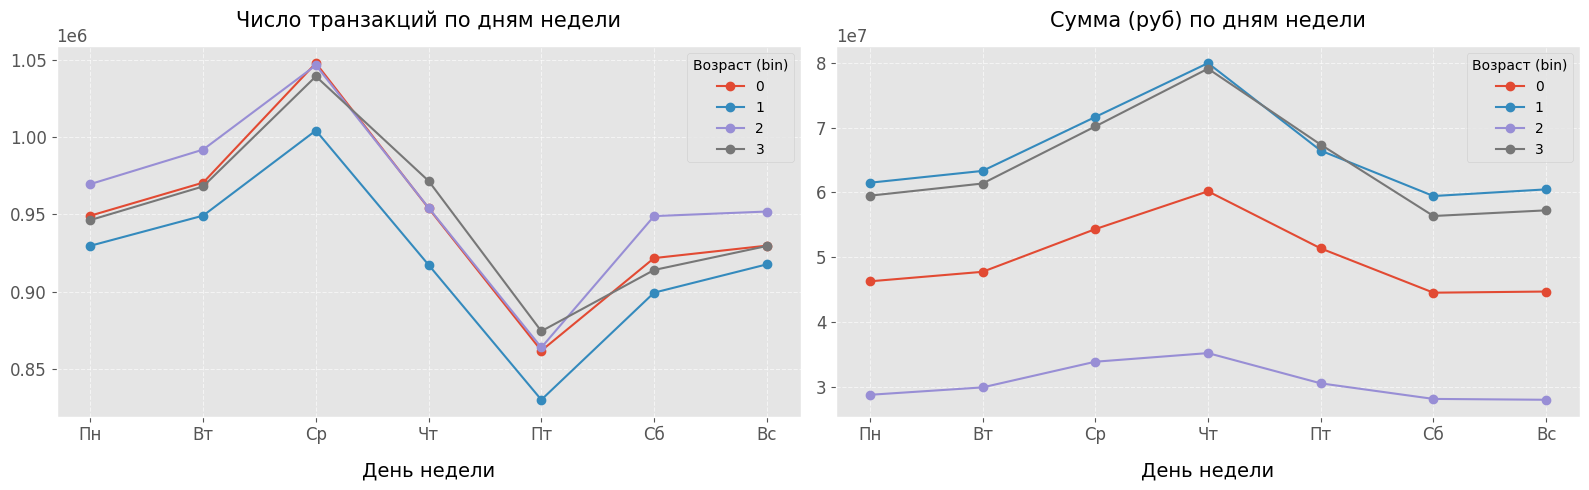

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(axes,
    ['count', 'sum'],
    ['Число транзакций', 'Сумма (руб)']):

    pivot = (df_desc
             .groupby(['bins', 'dayofweek'])['amount_rur']
             .agg(metric)
             .unstack('bins'))

    pivot.index = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
    pivot.plot(ax=ax, marker='o')
    ax.set_title(f'{title} по дням недели')
    ax.set_xlabel('День недели')
    ax.legend(title='Возраст (bin)')

plt.tight_layout()

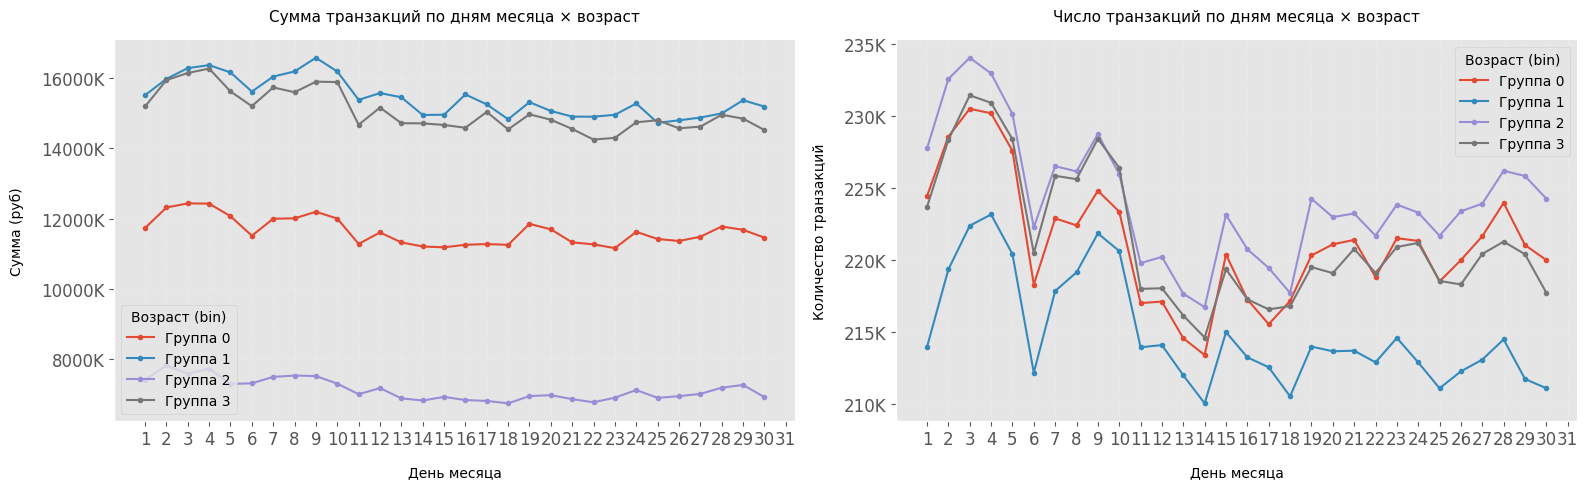

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Извлекаем день месяца (1–31)
# day_of_month = остаток от деления на 30 (или 31)
df_desc['day_of_month'] = (df_desc['trans_date'] % 30) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title, ylabel in zip(
    axes,
    ['sum', 'count'],
    ['Сумма транзакций по дням месяца × возраст',
     'Число транзакций по дням месяца × возраст'],
    ['Сумма (руб)', 'Количество транзакций']
):
    pivot = (df_desc
             .groupby(['bins', 'day_of_month'])['amount_rur']
             .agg(metric)
             .unstack('bins'))

    for col in pivot.columns:
        ax.plot(pivot.index, pivot[col],
                marker='o', markersize=3, linewidth=1.5,
                label=f'Группа {col}')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('День месяца', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(range(1, 32))
    ax.legend(title='Возраст (bin)')
    ax.grid(alpha=0.3, linestyle=':')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if metric=='sum' else f'{x/1e3:.0f}K')
    )

plt.tight_layout()
plt.show()

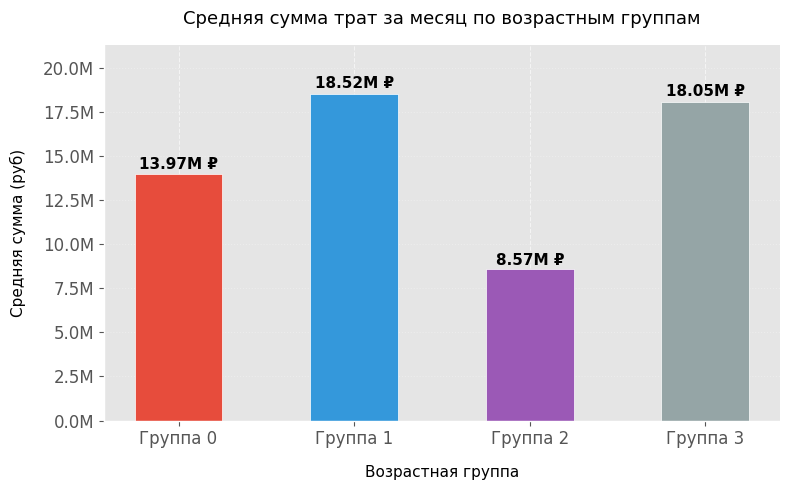

In [ ]:
df_desc['month'] = (df_desc['trans_date'] // 30) + 1

monthly_avg = (df_desc
    .groupby(['bins', 'month'])['amount_rur']
    .sum()
    .reset_index()
    .groupby('bins')['amount_rur']
    .mean()
    .reset_index()
    .rename(columns={'amount_rur': 'avg_monthly_sum', 'bins': 'Возрастная группа'}))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(monthly_avg['Возрастная группа'],
              monthly_avg['avg_monthly_sum'],
              color=['#e74c3c', '#3498db', '#9b59b6', '#95a5a6'],
              width=0.5, edgecolor='white')


for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + height * 0.01,
            f'{height/1e6:.2f}M ₽',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Средняя сумма трат за месяц по возрастным группам',
             fontsize=13, pad=15)
ax.set_xlabel('Возрастная группа', fontsize=11)
ax.set_ylabel('Средняя сумма (руб)', fontsize=11)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['Группа 0', 'Группа 1',
                     'Группа 2', 'Группа 3'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.set_ylim(0, monthly_avg['avg_monthly_sum'].max() * 1.15)

plt.tight_layout()
plt.show()

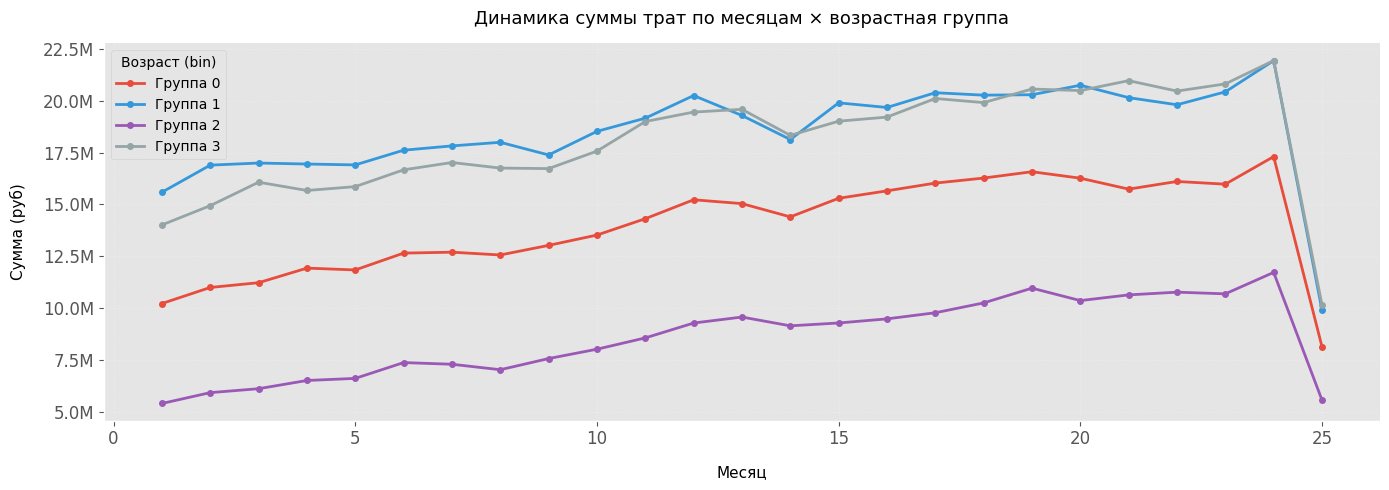

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

pivot = (df_desc
         .groupby(['bins', 'month'])['amount_rur']
         .sum()
         .unstack('bins'))

colors = ['#e74c3c', '#3498db', '#9b59b6', '#95a5a6']
for col, color in zip(pivot.columns, colors):
    ax.plot(pivot.index, pivot[col], marker='o', markersize=4,
            linewidth=2, color=color, label=f'Группа {col}')

ax.set_title('Динамика суммы трат по месяцам × возрастная группа', fontsize=13)
ax.set_xlabel('Месяц', fontsize=11)
ax.set_ylabel('Сумма (руб)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(title='Возраст (bin)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

# Итоговые выводы EDA-проекта

## Главный вопрос: можно ли узнать возраст клиента по его тратам?

**Да — и вот почему.**

---

## 1. Размер чека устойчиво различает группы

Иерархия среднего чека сохраняется **в любой день недели, в любой месяц, на протяжении всех 700 дней** наблюдений:

- Группа 1 (~ 46-55 лет) — стабильно лидирует (~75 руб. средний чек, 18.52M руб. в месяц), **самые высокие** показатели.
- Группа 3 (~ 36-45 лет) — рядом (~70 руб., 18.05M руб.), высокие показатели.
- Группа 0 (~ 26-35 лет) — ниже (~52 руб., 13.97M руб.), средние показатели.
- Группа 2 (молодежь, ~ 18-25 лет) — аномально низко (~30 руб., 8.57M руб.), **самый низкий** средний чек.

---

## 2. Категории трат — главный идентификатор возраста

График lift и графики bar показали конкретные категории-маркеры:

| Группа | Маркерные категории | Интерпретация |
|--------|-------------------|---------------|
| 2 — молодёжь (~ 18-25 лет) | видеоигры, кинотеатры, табачные магазины, спорт, одежда, каршеринг, онлайн магазины, среднее и высшее образование | Самые молодые, больше развлекательных категорий, алкоголь/табак |
| 0 — молодые (~ 26-35 лет) | детская одежда, магазин игрушек, доставка еды на дом, размещение рекламмы, азартные игры, похоронные услуги, санатории парки прогулки на природе, магазин игрушек, видеоигры, детская одежда, кинотеатры, одежда  | дети, забота о пожилых родителях
| 3 — зрелые (~ 36-45 лет) | Нумизматика, благотворительность и краудфандинг, услуги для дома, магазин игрушек, детская одежда, спорт, курсы, развлекательные места | Финансово активные, интересуются нумизматикой, инвестируют в краудфандинг, активный образ жизни, дети повзрослее |
| 1 — средний (~ 46-55 лет)| мясо и морепродукты, предметы декора, рукоделие, строительные материалы, прочие отели, авиабелеты, мебель и товары для дома | Финансово активные, домашний досуг, самые платежно-способные, домохозйство, качество жизни, свое жилье, путешествия, большая или повзрослее семья |

Это означает, что **поведенческий портрет каждой группы читается чётко** и логично соответствует жизненному циклу.

---

## 3. Что НЕ помогает определить возраст

- **День недели** — все группы ведут себя одинаково (пик в четверг, спад в пятницу-субботу универсален)
- **Топ-категории по количеству** — супермаркеты, фастфуд, телефония одинаково популярны у всех
- **Временной тренд** — все группы растут пропорционально, без расхождений

Это тоже ценный результат: он говорит о том, **какие признаки менее полезны** для модели предсказания возраста.


## 5. Общий вывод для бизнеса

Клиентов банка **можно сегментировать по возрасту** на основе транзакционных данных. Для этого достаточно нескольких признаков:

1. **Размер среднего чека** — самый простой и устойчивый сигнал
2. **Доля трат в маркерных категориях** — lift-категории дают точную сегментацию
3. **Соотношение частых и редких трат** — характеризует стиль потребления

Это открывает возможности для **таргетированных продуктов**: инвестиционные предложения для группы 3, кешбэк на товары для дома для группы 1, транспортные льготы для группы 3. Предположения о возрастной сегментации групп были сделаны основываясь на среднем чеке, объеме трат, характеризующих категорий, количествах транзакций. Банк может строить возрастные профили **без анкетных данных** — только на основе истории транзакций.

